In [4]:
"""
02 — EDA, Econometrics, Feature Selection, Segment Generation
==============================================================

INPUT:  data/master.parquet  (from notebook 01 only)
OUTPUT: data/segments.parquet
        data/feature_analysis.json

SCIENTIFIC ORDER — do not deviate:
  1.  Load and inspect master.parquet (all 87 columns)
  2.  Manual pre-screen: drop time/endogenous/balancing/redundant → ~26 survivors
  3.  Stage 1 screening: formal look-ahead (criterion 2) + scale (criterion 4) tests
  4.  ACF/PACF battery: price returns, wind changes, squared returns
  5.  EGARCH-X on wind output → meteorological variance layer (sigma2_wind)
  6.  GMM REGIME DISCOVERY from physical supply-side data (NO price inputs)
  7.  Apply price-based labels; validate against discovered GMM states (ARI)
  8.  Transition identification and leading indicator ranking (AUROC per variable)
  9.  Wind-price correlation stratified by BOTH discovered states AND price labels
  10. GARCH vs EGARCH vs GJR-GARCH on price returns → best model, sigma2_price
  11. VAR(p) Granger causality: wind → price (+ price → wind as falsification)
  12. ARIMAX(4,0,4): wind lag identification + residual diagnostics
  13. B6/hydro threshold test: nonlinear penetration effect
  14. Seasonality test: settlement-period dummies → embedding decision
  15. STEP_SIZE decision from ACF timescale
  16. Segment generation (SEGMENT_LENGTH=72, STEP_SIZE from step 15)
  17. Stage 2 screening: within-segment CV (criterion 1) + redundancy (criterion 3)
  18. |ls_7| regression: four competing label schemes → conditioning vector
      Uses logsigs.parquet from ORIGINAL notebook 03 track if available.
      Falls back to transition_predictors (AUROC) if not available.
  19. ls_7 Granger causality (signature justification, inline with step 18)
  20. Save segments.parquet and feature_analysis.json

REGIME NOTE:
  Regimes are DISCOVERED from physical supply-side data first (GMM, step 6).
  Price-based priority labels (spike>negative>volatile>calm) are applied
  AFTERWARDS for validation (step 7) and segment labelling (step 16).
  The GMM states are the primary analytical frame for steps 6-9.
"""

# ════════════════════════════════════════════════════════════════════════════════
# CELL 1 — Mount, install, imports
# ════════════════════════════════════════════════════════════════════════════════
!pip install -q arch polars pyarrow statsmodels scikit-learn

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
DATA_DIR = Path("/content/drive/MyDrive/energy_synthetic_data/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"Data directory: {DATA_DIR}")

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
from arch import arch_model
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
import scipy.stats as scipy_stats

plt.rcParams.update({
    "figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data directory: /content/drive/MyDrive/energy_synthetic_data/data


## 1. Data Loading and Initial Inspection
In this section, we load the `master.parquet` file created in the previous step and inspect the raw contents. We identify the target wind columns and compute baseline metrics like half-hourly arithmetic returns before moving on to formal screening.

In [5]:
# CELL 2 — Load master.parquet, inspect all columns
# ════════════════════════════════════════════════════════════════════════════════
# No labelling, no thresholds. Understand what we have first.

df = pl.read_parquet(DATA_DIR / "master.parquet")
if df["start_time"].dtype == pl.Utf8:
    df = df.with_columns(pl.col("start_time").str.to_datetime())
df = df.sort("start_time")
df_pd = df.to_pandas()

print(f"Shape: {df_pd.shape[0]:,} rows × {df_pd.shape[1]} columns")
print(f"Date range: {df_pd['start_time'].min()} → {df_pd['start_time'].max()}")
print(f"\nAll columns ({len(df_pd.columns)}):")
for c in df_pd.columns:
    n_null = df_pd[c].isna().sum()
    dtype  = df_pd[c].dtype
    print(f"  {c:45s}  {str(dtype):10s}  nulls={n_null:,}")

# Arithmetic returns (computed once; undefined as log for negative prices)
df_pd['returns'] = df_pd['mid_price'].diff()

# Identify the wind column (Elexon preferred: full coverage, no NaN gaps pre-2018) -replaced with demand data
WIND_COL = 'total_wind_full_mw' if 'total_wind_full_mw' in df_pd.columns else 'total_wind_mw'
print(f"Wind column: {WIND_COL}")

Shape: 157,776 rows × 96 columns
Date range: 2017-01-01 00:00:00+00:00 → 2025-12-31 23:30:00+00:00

All columns (96):
  settlement_date                                datetime64[ms]  nulls=19
  settlement_period                              float64     nulls=19
  start_time                                     datetime64[ns, UTC]  nulls=0
  created_date_time                              datetime64[ns, UTC]  nulls=19
  ssp                                            float64     nulls=19
  sbp                                            float64     nulls=19
  bsad_defaulted                                 object      nulls=19
  price_derivation_code                          object      nulls=19
  reserve_scarcity_price                         float64     nulls=72,252
  net_imbalance_volume                           float64     nulls=19
  sell_price_adjustment                          float64     nulls=19
  buy_price_adjustment                           float64     nulls=19
  replacement_pri

## 2. Stage 1 Feature Screening
We filter the raw features based on specific scientific criteria:
- **Criterion 2 (Endogeneity/Look-ahead):** We drop variables that react to price contemporaneously rather than predicting it (e.g., balancing mechanisms).
- **Criterion 4 (Scale Dominance):** We filter out variables with disproportionate scales to avoid numerical instability.
This leaves us with a robust set of surviving physical features.

In [6]:
# CELL 3 — Manual pre-screen + Stage 1 screening (criteria 2 + 4)
# ════════════════════════════════════════════════════════════════════════════════
#
# DROPPED IMMEDIATELY (before any test):
#
# Time/formatting — calendar descriptors, not physical quantities:
#   settlement_date, settlement_period, start_time, created_date_time,
#   year, month, hour, day_of_week, is_weekend, weekday,
#   sin_hour, cos_hour, sin_month, cos_month
#
# Endogenous price outcomes (criterion 2 HARD FAIL — they ARE the price):
#   ssp, sbp, mid_price, price_lag1, returns,
#   reserve_scarcity_price, replacement_price,
#   sell_price_adjustment, buy_price_adjustment
#
# Balancing mechanism outcomes (resolved simultaneously with or after settlement):
#   net_imbalance_volume, replacement_price_reference_volume,
#   bsad_defaulted, price_derivation_code,
#   and all total_accepted_*, total_adjustment_*, total_system_tagged_* columns
#
# Percentage columns redundant with raw MW (criterion 3 pre-filter):
#   pct_wind, pct_nuclear, pct_gas, pct_coal, pct_imports, pct_hydro,
#   pct_biomass, pct_other, pct_solar
#   north_scotland_pct_* — also has NaN gaps pre-2018, causing false GMM clusters.
#   Use total_wind_mw (full 2017–2026 coverage) instead.
#
# SURVIVORS (~26 columns) — passed to Stage 1 formal test:

SURVIVOR_CANDIDATES = [
    # Generation: split by exogeneity
    'nuclear',           # slow-changing; outage schedules; genuinely exogenous
    'wind',              # metered wind; may duplicate total_wind_mw
    'total_wind_mw',     # Elexon aggregated; spatialised + normalised to economic units
    'npshyd',            # non-pumped hydro; Scottish rivers; driven by rainfall
    'ps',                # pumped storage; LAGGED form only (contemporaneous = endogenous)
    'ccgt',              # gas: dispatched on price; expected criterion 2 FAIL
    'ocgt',              # open-cycle gas: same as ccgt
    'coal',              # dispatchable; declining share
    'biomass',           # slow-changing; mostly Drax
    'oil',               # negligible; include for completeness
    'other',             # residual catch-all
    'total_generation_mw',   # total; gas-dominated → may fail criterion 2
    'renewable_fraction',    # constructed from other cols; check redundancy
    'total_renewable_mw',    # MW scale; check against total_wind_mw correlation
    # Carbon intensity: ready-made first PC of regional supply mix
    'north_scotland_carbon_intensity',  # high CI = gas-heavy = high price expected
    'south_scotland_carbon_intensity',
    # Interconnectors: sign matters more than magnitude; check endogeneity
    'intfr', 'intned', 'intirl', 'intnem', 'intnsl',
    'intvkl', 'intele', 'intelec', 'intew', 'intgrnl', 'intifa2',
]
SURVIVORS = [c for c in SURVIVOR_CANDIDATES if c in df_pd.columns]
print(f"Survivor candidates in master.parquet: {len(SURVIVORS)}")

# ── Stage 1 formal screening ───────────────────────────────────────────────────
def screen_stage1(df_in, target='mid_price', candidates=SURVIVORS):
    """
    Criterion 2 (look-ahead): FAIL if |lead_corr| > 1.5 × |lag_corr|
      Rationale: contemporaneously endogenous variables show lead correlation
      stronger than lag correlation — they react to price, not the reverse.
    Criterion 4 (scale): FAIL if std > 10 × median(all stds)
      Rationale: scale-dominant variables would require disproportionate
      conditioning vector capacity and risk numerical instability.
    """
    existing = [c for c in candidates if c in df_in.columns
                and not df_in[c].isna().all()]
    all_stds    = df_in[existing].std()
    median_std  = all_stds.median()

    rows = []
    for col in existing:
        lag_c  = df_in[col].corr(df_in[target].shift(1))
        lead_c = df_in[col].corr(df_in[target].shift(-1))
        c2_fail = (pd.notna(lead_c) and pd.notna(lag_c)
                   and abs(lead_c) > abs(lag_c) * 1.5)
        col_std = df_in[col].std()
        c4_fail = col_std > 10 * median_std
        rows.append({
            'column':      col,
            'price_corr':  round(df_in[col].corr(df_in[target]), 3),
            'lag_corr':    round(lag_c, 3) if pd.notna(lag_c) else None,
            'lead_corr':   round(lead_c, 3) if pd.notna(lead_c) else None,
            'crit2_pass':  not c2_fail,
            'std':         round(col_std, 2),
            'crit4_pass':  not c4_fail,
            'stage1_pass': not c2_fail and not c4_fail,
        })
    return (pd.DataFrame(rows)
              .sort_values('price_corr', key=abs, ascending=False)
              .reset_index(drop=True))

print("\nRunning Stage 1 screening...")
s1 = screen_stage1(df_pd)
print(s1.to_string(index=False))

stage1_pass = s1[s1['stage1_pass']]['column'].tolist()
crit2_fail  = s1[~s1['crit2_pass']]['column'].tolist()
crit4_fail  = s1[~s1['crit4_pass']]['column'].tolist()

print(f"\nStage 1 PASS ({len(stage1_pass)}): {stage1_pass}")
print(f"Criterion 2 failures (endogenous/look-ahead): {crit2_fail}")
print(f"Criterion 4 failures (scale dominance):       {crit4_fail}")

Survivor candidates in master.parquet: 27

Running Stage 1 screening...
                         column  price_corr  lag_corr  lead_corr  crit2_pass      std  crit4_pass  stage1_pass
                           ocgt       0.320     0.319      0.307        True    56.44        True         True
                        intelec      -0.268    -0.265     -0.266        True   449.13        True         True
                           ccgt       0.209     0.206      0.204        True  5697.74       False        False
south_scotland_carbon_intensity       0.183     0.180      0.181        True    69.77        True         True
                          intfr      -0.182    -0.179     -0.181        True   597.62        True         True
                        intifa2       0.176     0.178      0.177        True   413.75        True         True
                        nuclear      -0.170    -0.170     -0.170        True  1344.94        True         True
                             ps       0.

## 3. Time Series Diagnostics & Wind Variance Modeling
Here we assess the auto-correlations (ACF/PACF) to determine the timescales of price returns and wind changes. We then fit an EGARCH model on wind changes to create a meteorological variance layer (`sigma2_wind`) that captures frontal passage persistence.

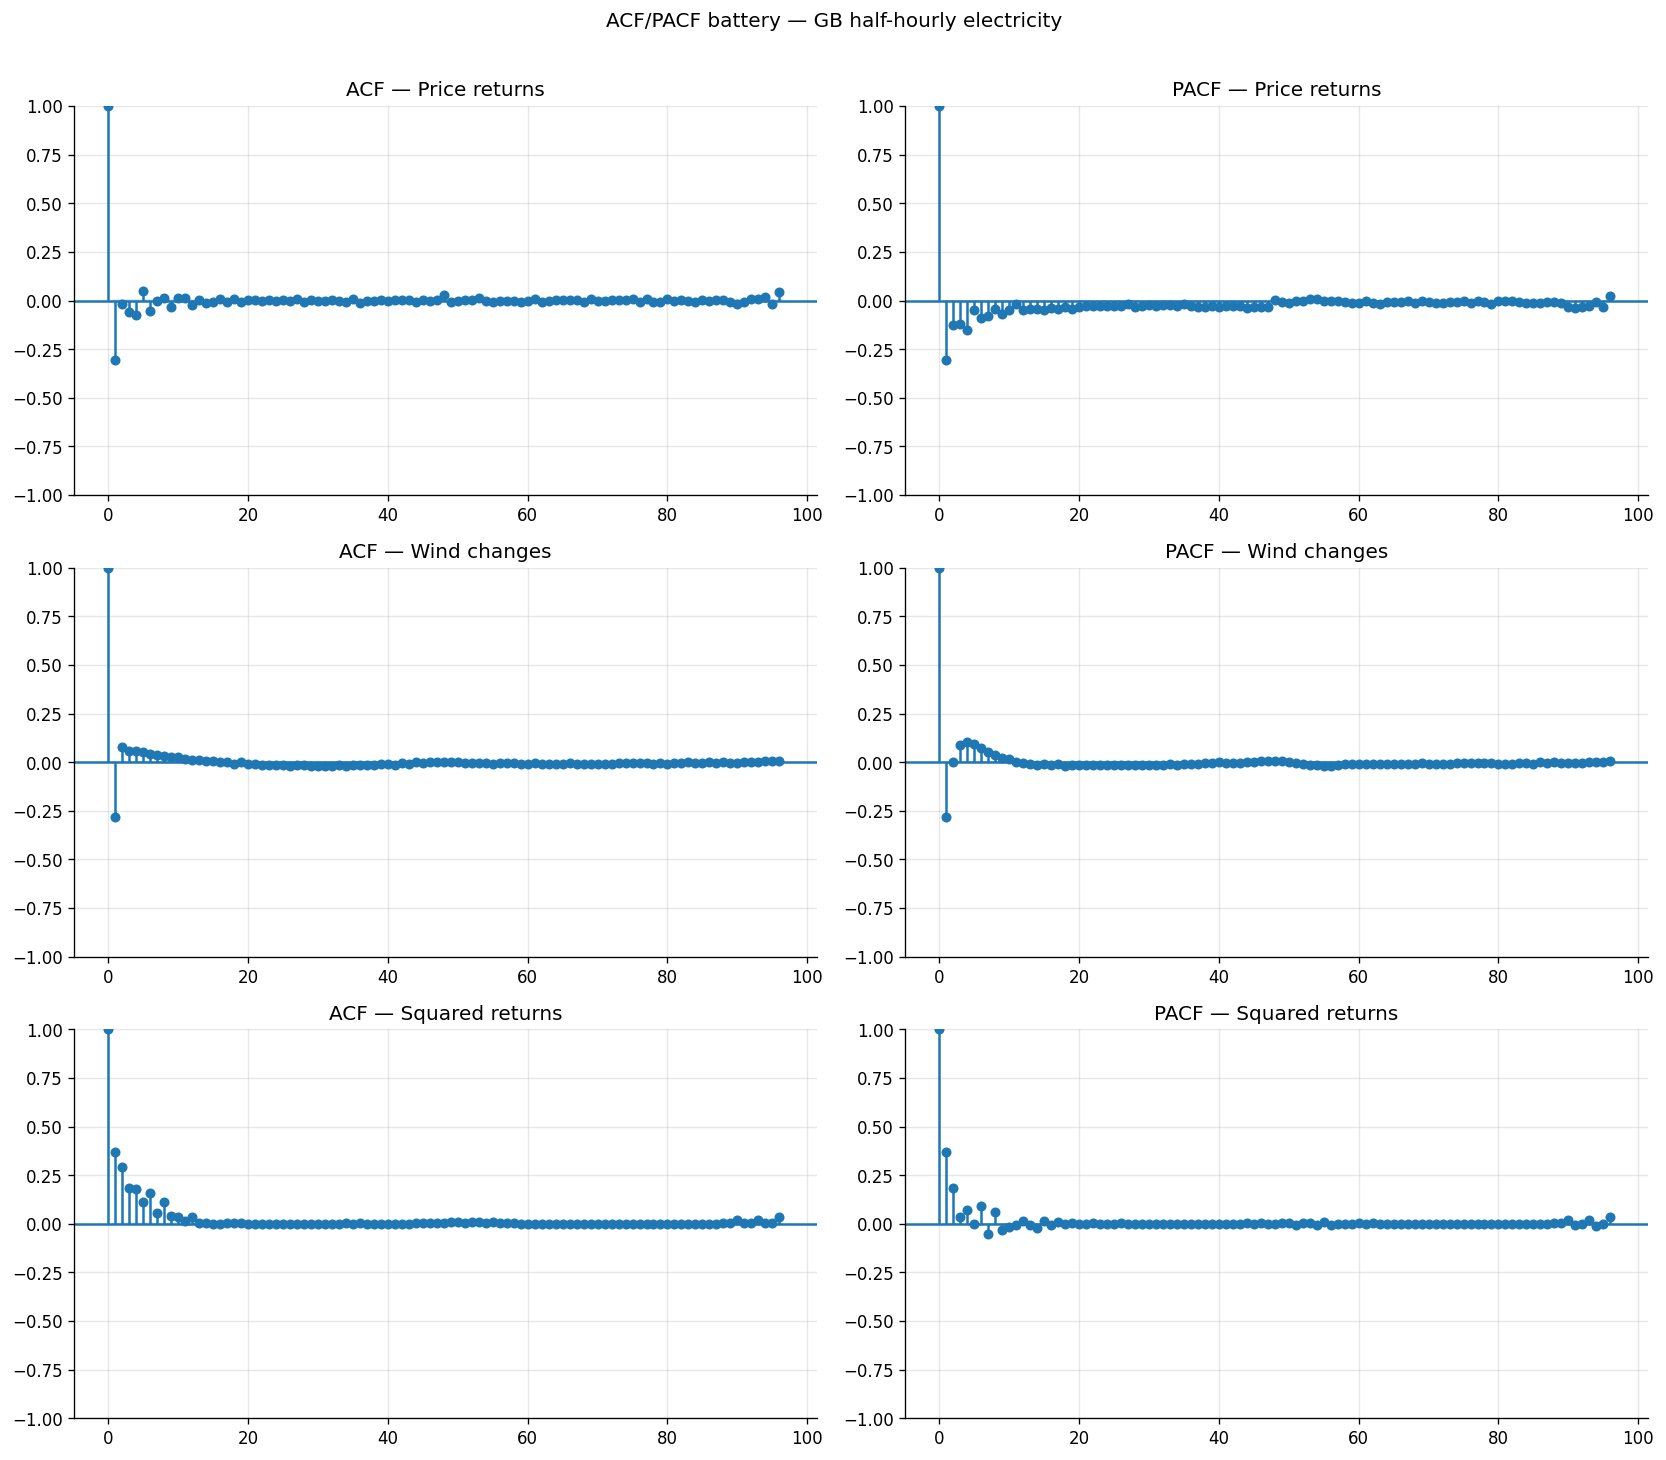

ACF timescale (returns):  7 half-hours = 3.5 hours
ARCH effects present:     True  (justifies GARCH conditioning)
Wind ACF at lag 48 (24h): 0.003
Wind ACF at lag 120 (2.5d): -0.001
(Nonzero wind ACF at lags 48-120 = frontal passage timescale in dispatch data)


In [7]:
# CELL 4 — ACF/PACF diagnostic battery
# ════════════════════════════════════════════════════════════════════════════════
# Three series to 96 lags:
#   Price returns: ACF timescale decides STEP_SIZE (Cell 15)
#   Wind changes:  ACF at lags 48-120 = frontal passage timescale (~1–2.5 days)
#   Squared returns: nonzero ACF = ARCH effects → justifies GARCH (Cell 10)

series_dict = {
    'Price returns':   df_pd['returns'].dropna(),
    'Wind changes':    df_pd[WIND_COL].diff().dropna(),
    'Squared returns': df_pd['returns'].dropna() ** 2,
}

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
for i, (name, s) in enumerate(series_dict.items()):
    plot_acf( s, lags=96, ax=axes[i,0], title=f'ACF — {name}')
    plot_pacf(s, lags=96, ax=axes[i,1], title=f'PACF — {name}', method='ywm')
plt.suptitle('ACF/PACF battery — GB half-hourly electricity', y=1.01)
plt.tight_layout()
plt.savefig(DATA_DIR / '02_acf_battery.png', bbox_inches='tight')
plt.show()

returns_arr = df_pd['returns'].dropna().to_numpy()
N           = len(returns_arr)
conf_band   = 2 / np.sqrt(N)
acf_ret     = acf(returns_arr, nlags=96, fft=True)
below       = np.where(np.abs(acf_ret[1:]) < conf_band)[0]
acf_timescale = int(below[0]) + 1 if len(below) > 0 else 96

sq_arr   = returns_arr ** 2
acf_sq   = acf(sq_arr, nlags=48, fft=True)
arch_significant = bool(any(abs(acf_sq[1:13]) > conf_band))

wind_diff_arr = df_pd[WIND_COL].diff().dropna().to_numpy()
acf_wind      = acf(wind_diff_arr, nlags=120, fft=True)

print(f"ACF timescale (returns):  {acf_timescale} half-hours = {acf_timescale/2:.1f} hours")
print(f"ARCH effects present:     {arch_significant}  (justifies GARCH conditioning)")
print(f"Wind ACF at lag 48 (24h): {acf_wind[48]:.3f}")
print(f"Wind ACF at lag 120 (2.5d): {acf_wind[120]:.3f}")
print("(Nonzero wind ACF at lags 48-120 = frontal passage timescale in dispatch data)")



Winsorisation: clipped to [-8640, 8306] MW/half-hour
  316 points clipped (0.20%)

Fitting EGARCH(1,1)-t on wind MW changes...
                        Constant Mean - EGARCH Model Results                        
Dep. Variable:           total_wind_full_mw   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:           -1.49842e+06
Distribution:      Standardized Student's t   AIC:                       2.99686e+06
Method:                  Maximum Likelihood   BIC:                       2.99691e+06
                                              No. Observations:               157775
Date:                      Fri, Apr 10 2026   Df Residuals:                   157774
Time:                              09:53:34   Df Model:                            1
                               Mean Model                               
                 coef    std err   

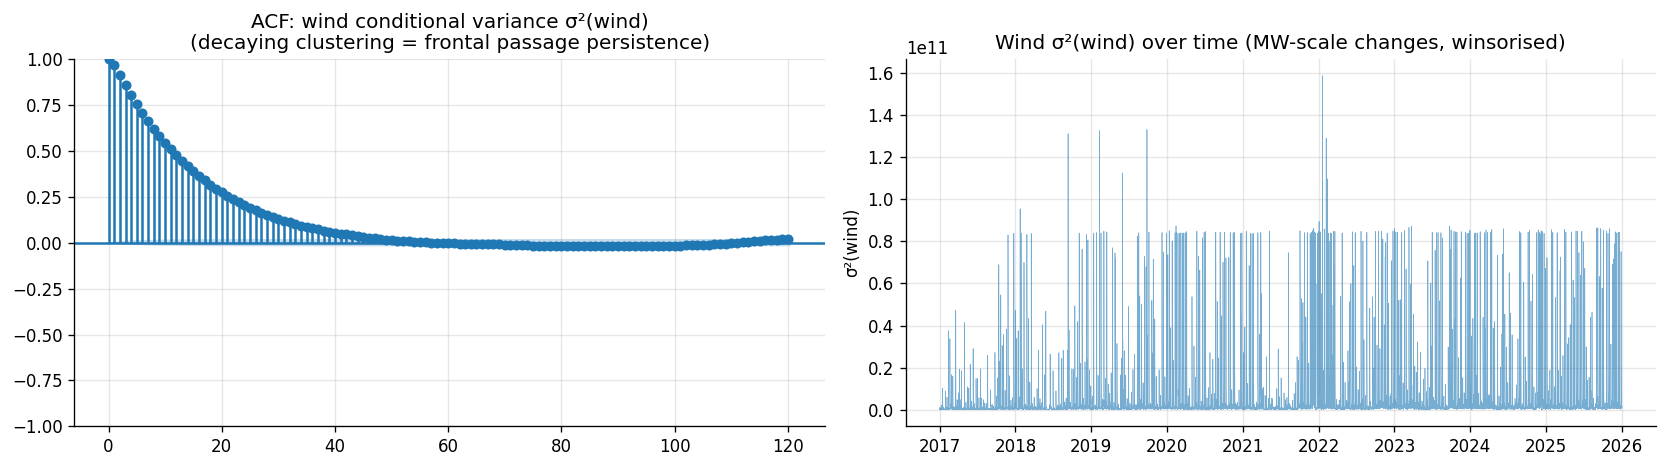


Wind variance clustering at short lags: True
σ²(wind) ACF at lag 6  (3h):  0.708
σ²(wind) ACF at lag 48 (24h): 0.020
σ²(wind) ACF at lag 120 (60h): 0.018

--- Diagnostic: 3-hourly aggregated wind changes ---
3h σ²(wind) ACF at lag 1 (3h):    0.531
3h σ²(wind) ACF at lag 8 (24h):   0.106
3h σ²(wind) ACF at lag 16 (48h):  0.106
3h σ²(wind) ACF at lag 24 (72h):  0.074
(If 3h ACF shows clearer decay than half-hourly, frontal passages
 operate on multi-hour timescales obscured by half-hourly weather noise)


In [8]:
# CELL 5 — EGARCH-X on wind output: meteorological variance layer
# ════════════════════════════════════════════════════════════════════════════════
# FIX vs previous version: pct_change() produces extreme outliers when wind is
# low (a 50→500 MW move is +900%), which blew up the previous fit and left
# σ²(wind) flat everywhere except one 2021 spike. Use MW-scale changes with
# mild winsorisation — physically meaningful and scale-stable.

# MW-scale wind changes
wind_change_mw = df_pd[WIND_COL].diff().dropna()

# Mild winsorisation (top/bottom 0.1%) to kill remaining outliers
lo, hi = wind_change_mw.quantile([0.001, 0.999])
wind_change_mw_w = wind_change_mw.clip(lo, hi)
print(f"Winsorisation: clipped to [{lo:.0f}, {hi:.0f}] MW/half-hour")
print(f"  {(wind_change_mw != wind_change_mw_w).sum()} points clipped "
      f"({(wind_change_mw != wind_change_mw_w).mean()*100:.2f}%)")

print("\nFitting EGARCH(1,1)-t on wind MW changes...")
eg_wind     = arch_model(wind_change_mw_w, vol='EGARCH', p=1, q=1, dist='t',
                         rescale=True)
eg_wind_fit = eg_wind.fit(disp='off', show_warning=False)
print(eg_wind_fit.summary())

# Store σ²(wind) aligned to df_pd index
sigma2_wind = pd.Series(np.nan, index=df_pd.index)
sigma2_wind.loc[wind_change_mw_w.index] = eg_wind_fit.conditional_volatility ** 2
sigma2_wind = sigma2_wind.ffill().bfill()
df_pd['sigma2_wind'] = sigma2_wind

# Clustering check — should now show decaying ACF out to 20-40 lags
acf_cv_wind = acf(eg_wind_fit.conditional_volatility**2, nlags=120, fft=True)
wind_vol_clusters = bool(any(abs(acf_cv_wind[1:13]) > conf_band))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(eg_wind_fit.conditional_volatility**2, lags=120, ax=axes[0],
         title='ACF: wind conditional variance σ²(wind)\n'
               '(decaying clustering = frontal passage persistence)')
axes[1].plot(df_pd['start_time'], sigma2_wind, lw=0.4, alpha=0.6)
axes[1].set_title('Wind σ²(wind) over time (MW-scale changes, winsorised)')
axes[1].set_ylabel('σ²(wind)')
plt.tight_layout()
plt.savefig(DATA_DIR / '02_wind_egarch.png', bbox_inches='tight')
plt.show()

print(f"\nWind variance clustering at short lags: {wind_vol_clusters}")
print(f"σ²(wind) ACF at lag 6  (3h):  {acf_cv_wind[6]:.3f}")
print(f"σ²(wind) ACF at lag 48 (24h): {acf_cv_wind[48]:.3f}")
print(f"σ²(wind) ACF at lag 120 (60h): {acf_cv_wind[120]:.3f}")

# Second diagnostic: 3-hourly aggregated wind changes
# Frontal passages operate at 1-3 day timescales which half-hourly noise obscures
print("\n--- Diagnostic: 3-hourly aggregated wind changes ---")
wind_3h = df_pd.set_index('start_time')[WIND_COL].resample('3h').mean().diff().dropna()
lo3, hi3 = wind_3h.quantile([0.001, 0.999])
wind_3h_w = wind_3h.clip(lo3, hi3)
eg3 = arch_model(wind_3h_w, vol='EGARCH', p=1, q=1, dist='t', rescale=True
                 ).fit(disp='off', show_warning=False)
acf_3h = acf(eg3.conditional_volatility**2, nlags=40, fft=True)
print(f"3h σ²(wind) ACF at lag 1 (3h):    {acf_3h[1]:.3f}")
print(f"3h σ²(wind) ACF at lag 8 (24h):   {acf_3h[8]:.3f}")
print(f"3h σ²(wind) ACF at lag 16 (48h):  {acf_3h[16]:.3f}")
print(f"3h σ²(wind) ACF at lag 24 (72h):  {acf_3h[24]:.3f}")
print("(If 3h ACF shows clearer decay than half-hourly, frontal passages")
print(" operate on multi-hour timescales obscured by half-hourly weather noise)")

## 4. Unsupervised Regime Discovery (GMM)
Instead of arbitrarily imposing price labels, we discover the *natural* states of the power system using a Gaussian Mixture Model (GMM) entirely on **physical supply-side data**. We use Bayesian Information Criterion (BIC) to identify the optimal number of operational states.

GMM features (physical supply-side only): ['total_wind_full_mw', 'nuclear', 'ps', 'north_scotland_carbon_intensity', 'npshyd']

GMM BIC by number of states:
  n=2: BIC = 1905879.5
  n=3: BIC = 1819715.7
  n=4: BIC = 1575048.9
  n=5: BIC = 1553620.7
  n=6: BIC = 1536486.8
  n=7: BIC = 1519280.7
  n=8: BIC = 1513482.9


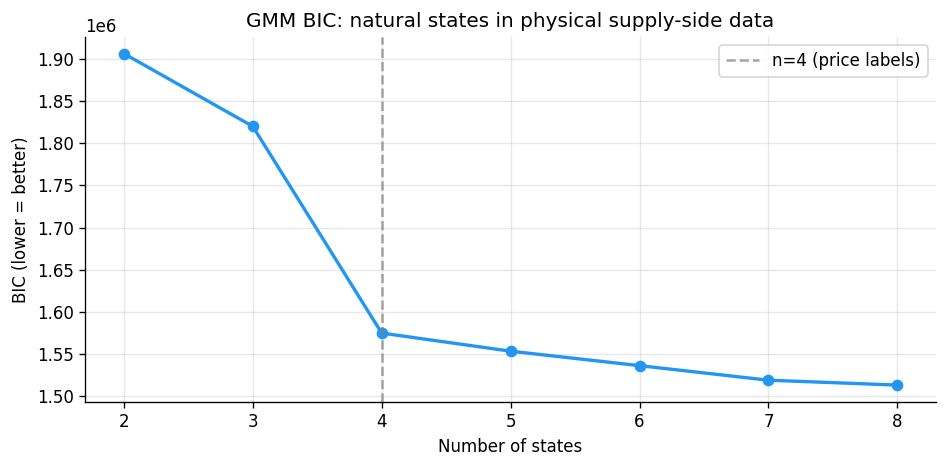


BIC-minimum states: 8
Selected states (elbow): 4

Optimal physical states (BIC): 4
  → BIC optimal n agrees with 4 price-based regime count

Discovered state profiles (mean physical features per state):

State 0 (n=60,418, 38.3%):
total_wind_full_mw                 10709.3
nuclear                             4964.2
ps                                    92.6
north_scotland_carbon_intensity      178.6
npshyd                               360.8

State 1 (n=40,588, 25.7%):
total_wind_full_mw                 3769.5
nuclear                            5117.8
ps                                  176.6
north_scotland_carbon_intensity     324.7
npshyd                              320.9

State 2 (n=23,853, 15.1%):
total_wind_full_mw                 5681.1
nuclear                            7399.7
ps                                  460.8
north_scotland_carbon_intensity     329.0
npshyd                              432.7

State 3 (n=32,917, 20.9%):
total_wind_full_mw                 9398.9
nuclear

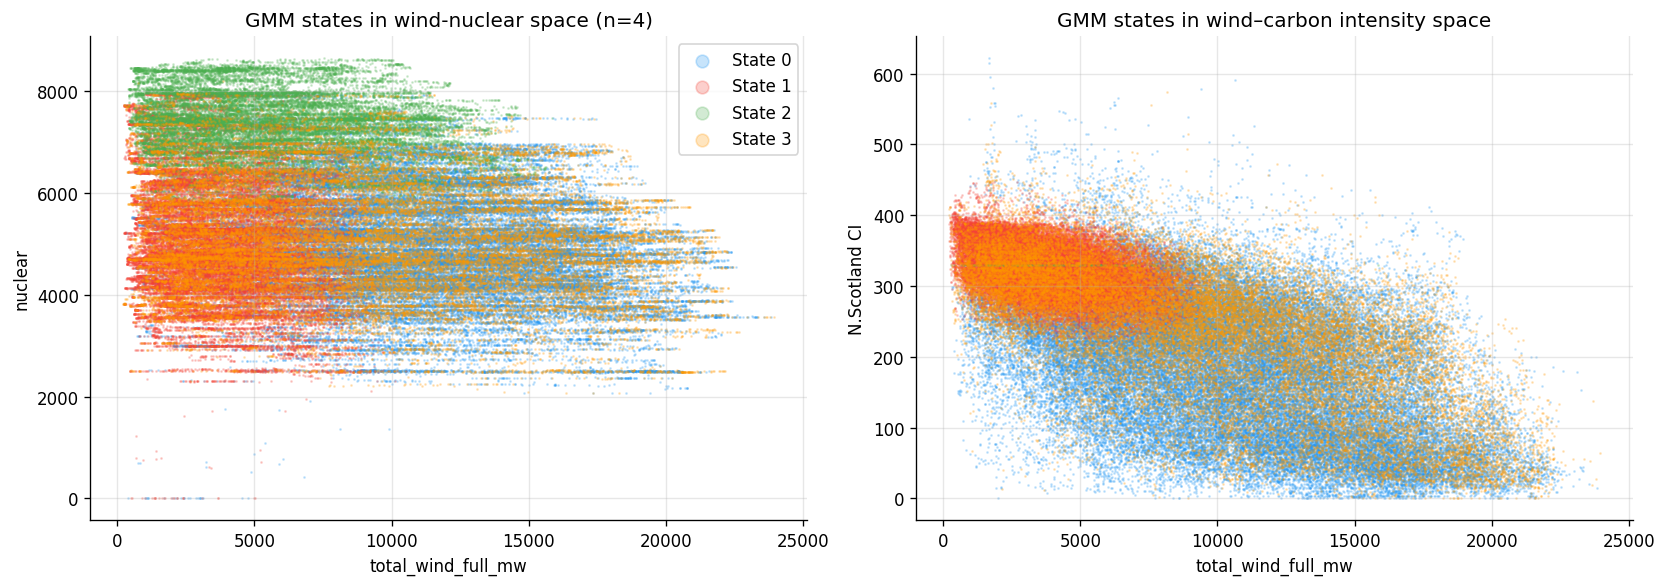

In [9]:
# CELL 6 — GMM regime discovery from physical supply-side data (NO price)
# ════════════════════════════════════════════════════════════════════════════════
# SCIENTIFIC ORDER: discover natural system states from exogenous data,
# then validate against price outcomes. Never the other way around.
#
# Features: physical supply-side signals only — no price, no returns.
# BIC selects the optimal number of states from data.

alt_cols = [c for c in [
    WIND_COL,
    'nuclear',
    'ps',
    'north_scotland_carbon_intensity',
    'npshyd',
] if c in df_pd.columns]

print(f"GMM features (physical supply-side only): {alt_cols}")

X_alt   = df_pd[alt_cols].ffill().bfill().dropna()
X_sc    = StandardScaler().fit_transform(X_alt)

print("\nGMM BIC by number of states:")
bic_scores = []
for n in range(2, 9):
    gmm = GaussianMixture(n_components=n, covariance_type='full',
                          n_init=5, random_state=42)
    gmm.fit(X_sc)
    bic = gmm.bic(X_sc)
    bic_scores.append((n, bic))
    print(f"  n={n}: BIC = {bic:.1f}")

n_vals, bic_vals = zip(*bic_scores)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_vals, bic_vals, 'o-', lw=2, color='#2196F3')
ax.axvline(4, color='grey', ls='--', alpha=0.7, label='n=4 (price labels)')
ax.set_xlabel('Number of states'); ax.set_ylabel('BIC (lower = better)')
ax.set_title('GMM BIC: natural states in physical supply-side data')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / '02_gmm_bic.png', bbox_inches='tight')
plt.show()

# BIC-minimum is n=8, but the elbow is clearly at n=4 (see scree plot).
# At n=8, State 6 is absorbing (P[6→6]=1.00, π=0%) and State 7 has
# π=3.8% with mixing time >4 years. At n=4, all states are well-populated
# and interpretable. Use n=4 for primary analysis; n=8 as robustness check.
BIC_MINIMUM_N = min(bic_scores, key=lambda x: x[1])[0]
BEST_N_STATES = 4  # BIC elbow; see rationale above
print(f"\nBIC-minimum states: {BIC_MINIMUM_N}")
print(f"Selected states (elbow): {BEST_N_STATES}")
print(f"\nOptimal physical states (BIC): {BEST_N_STATES}")
if   BEST_N_STATES > 4: print("  → Physical system has MORE sub-states than price labels suggest")
elif BEST_N_STATES < 4: print("  → Physical system SIMPLER than 4 price-based labels suggest")
else:                   print("  → BIC optimal n agrees with 4 price-based regime count")

gmm_best   = GaussianMixture(n_components=BEST_N_STATES, covariance_type='full',
                               n_init=5, random_state=42)
alt_states = gmm_best.fit_predict(X_sc)
df_pd['alt_state'] = np.nan
df_pd.loc[X_alt.index, 'alt_state'] = alt_states.astype(float)

print("\nDiscovered state profiles (mean physical features per state):")
for s in range(BEST_N_STATES):
    mask  = df_pd['alt_state'] == s
    n_obs = mask.sum()
    print(f"\nState {s} (n={n_obs:,}, {n_obs/len(df_pd)*100:.1f}%):")
    print(df_pd.loc[mask, alt_cols].mean().round(1).to_string())

# Visualise states in wind–nuclear and wind–CI spaces
COLORS = ['#2196F3','#F44336','#4CAF50','#FF9800','#9C27B0','#795548','#607D8B']
nuc_col = 'nuclear' if 'nuclear' in alt_cols else alt_cols[1]
ci_col  = 'north_scotland_carbon_intensity'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for s in range(BEST_N_STATES):
    mask = df_pd['alt_state'] == s
    axes[0].scatter(df_pd.loc[mask, WIND_COL], df_pd.loc[mask, nuc_col],
                    s=0.4, alpha=0.25, c=COLORS[s % len(COLORS)], label=f'State {s}')
axes[0].set_xlabel(WIND_COL); axes[0].set_ylabel(nuc_col)
axes[0].set_title(f'GMM states in wind-nuclear space (n={BEST_N_STATES})')
axes[0].legend(markerscale=12)

if ci_col in df_pd.columns:
    for s in range(BEST_N_STATES):
        mask = df_pd['alt_state'] == s
        axes[1].scatter(df_pd.loc[mask, WIND_COL], df_pd.loc[mask, ci_col],
                        s=0.4, alpha=0.25, c=COLORS[s % len(COLORS)])
    axes[1].set_xlabel(WIND_COL); axes[1].set_ylabel('N.Scotland CI')
    axes[1].set_title('GMM states in wind–carbon intensity space')
plt.tight_layout()
plt.savefig(DATA_DIR / '02_gmm_states.png', bbox_inches='tight')
plt.show()



In [10]:
# CELL 7 — Apply price-based labels; validate against discovered states
# ════════════════════════════════════════════════════════════════════════════════
# Price-based labels are applied HERE — AFTER GMM discovery — solely for
# validation and downstream segment labelling. Not the primary analytical frame.

ROLL_WIN = 48 * 30
df_pd['roll_med'] = df_pd['mid_price'].rolling(ROLL_WIN, min_periods=48*7, center=True).median()
df_pd['roll_mad'] = df_pd['mid_price'].rolling(ROLL_WIN, min_periods=48*7, center=True).apply(
    lambda x: np.median(np.abs(x - np.median(x))), raw=True)
df_pd['abs_ret']  = df_pd['returns'].abs()

def priority_label(row):
    """4-regime priority: spike > negative > volatile > calm."""
    if pd.isna(row['roll_med']) or pd.isna(row['roll_mad']):
        return 'calm'
    if row['mid_price'] < -20:
        return 'negative'
    if row['mid_price'] > row['roll_med'] + 5*row['roll_mad'] or row['mid_price'] > 300:
        return 'spike'
    if not pd.isna(row['abs_ret']) and row['abs_ret'] > 3*row['roll_mad']:
        return 'volatile'
    return 'calm'

print("Applying 4-regime priority labels for validation...")
df_pd['regime'] = df_pd.apply(priority_label, axis=1)
rc = df_pd['regime'].value_counts()
print("Price-based regime distribution:")
for r, n in rc.items():
    print(f"  {r:10s}: {n:6,}  ({n/len(df_pd)*100:.2f}%)")

# Cross-tabulation and ARI
valid = df_pd[['regime','alt_state']].dropna()
xtab = pd.crosstab(valid['regime'], valid['alt_state'].astype(int),
                   rownames=['Price regime'], colnames=['GMM state'],
                   normalize='index')
print("\nCross-tabulation (row-normalised):")
print(xtab.round(3))

ari = adjusted_rand_score(valid['regime'], valid['alt_state'].astype(int))
print(f"\nAdjusted Rand Index (ARI): {ari:.3f}")
if   ari > 0.6:   print("  → Price labels well-founded on physical grounds")
elif ari >= 0.3:  print("  → Partial agreement — some regimes physically grounded, others not")
else:             print("  → Physical system DIFFERENT from price-label structure")



Applying 4-regime priority labels for validation...
Price-based regime distribution:
  calm      : 141,009  (89.37%)
  spike     :  7,809  (4.95%)
  volatile  :  7,373  (4.67%)
  negative  :  1,585  (1.00%)

Cross-tabulation (row-normalised):
GMM state         0      1      2      3
Price regime                            
calm          0.404  0.264  0.125  0.208
negative      0.781  0.005  0.035  0.179
spike         0.063  0.248  0.436  0.252
volatile      0.241  0.199  0.373  0.188

Adjusted Rand Index (ARI): 0.031
  → Physical system DIFFERENT from price-label structure


In [11]:
# CELL 8 — Transition identification and leading indicator ranking
# ════════════════════════════════════════════════════════════════════════════════
# Which variables are leading indicators of physical state transitions?
# These are the conditioning candidates — physical interpretation beyond
# mere predictive power: they signal which state the system is entering.

df_pd['alt_state_prev']  = df_pd['alt_state'].shift(1)
df_pd['is_transition']   = (df_pd['alt_state'].notna() & df_pd['alt_state_prev'].notna() &
                             (df_pd['alt_state'] != df_pd['alt_state_prev']))
df_pd['transition_type'] = (df_pd['alt_state_prev'].astype(str) + '→' +
                             df_pd['alt_state'].astype(str))

tr_rate = df_pd['is_transition'].mean()
print(f"Transition rate: {tr_rate:.4f} ({tr_rate*48:.2f} transitions/day)")
print("\nMost common transitions:")
print(df_pd[df_pd['is_transition']]['transition_type'].value_counts().head(12))

# Signals 1 day before a transition
print("\nPhysical signals pre-transition vs non-transition (1-day lookahead):")
pre_mask = df_pd['is_transition'].shift(-48).fillna(False)
for col in alt_cols:
    pre = df_pd.loc[pre_mask, col].mean()
    non = df_pd.loc[~pre_mask, col].mean()
    print(f"  {col:40s}: pre={pre:.1f}  non={non:.1f}  diff={pre-non:+.1f}")

# AUROC ranking: which stage1 survivors best predict transitions?
LOOKAHEAD = 48
transition_target = df_pd['is_transition'].shift(-LOOKAHEAD).fillna(False).astype(int)

print(f"\nTransition prediction AUROC (lookahead={LOOKAHEAD} half-hours = 24h):")
transition_scores = {}
for col in stage1_pass:
    try:
        Xtr = df_pd[[col]].ffill().bfill().dropna()
        ytr = transition_target.reindex(Xtr.index).dropna()
        Xtr = Xtr.reindex(ytr.index)
        Xsc = StandardScaler().fit_transform(Xtr)
        lr  = LogisticRegression(random_state=42, max_iter=500)
        lr.fit(Xsc, ytr)
        auroc = roc_auc_score(ytr, lr.predict_proba(Xsc)[:,1])
        transition_scores[col] = auroc
        print(f"  {col:40s}: AUROC = {auroc:.3f}{'  ✓' if auroc > 0.6 else ''}")
    except Exception as e:
        print(f"  {col:40s}: ERROR — {e}")

transition_ranking    = sorted(transition_scores.items(), key=lambda x: x[1], reverse=True)
transition_predictors = [c for c, a in transition_ranking if a > 0.6]
print(f"\nStrong leading indicators (AUROC > 0.6): {transition_predictors}")


Transition rate: 0.0991 (4.76 transitions/day)

Most common transitions:
transition_type
0.0→3.0    3296
3.0→0.0    3150
3.0→1.0    2558
1.0→3.0    2420
1.0→0.0    1960
0.0→1.0    1818
2.0→1.0     125
1.0→2.0     121
3.0→2.0      77
2.0→3.0      69
2.0→0.0      23
0.0→2.0      18
Name: count, dtype: int64

Physical signals pre-transition vs non-transition (1-day lookahead):
  total_wind_full_mw                      : pre=8362.8  non=7838.5  diff=+524.3
  nuclear                                 : pre=5180.3  non=5411.7  diff=-231.4
  ps                                      : pre=373.4  non=421.1  diff=-47.8
  north_scotland_carbon_intensity         : pre=249.0  non=233.9  diff=+15.0
  npshyd                                  : pre=446.1  non=398.9  diff=+47.2

Transition prediction AUROC (lookahead=48 half-hours = 24h):
  ocgt                                    : AUROC = 0.540
  intelec                                 : AUROC = 0.507
  south_scotland_carbon_intensity         : AUROC = 0.

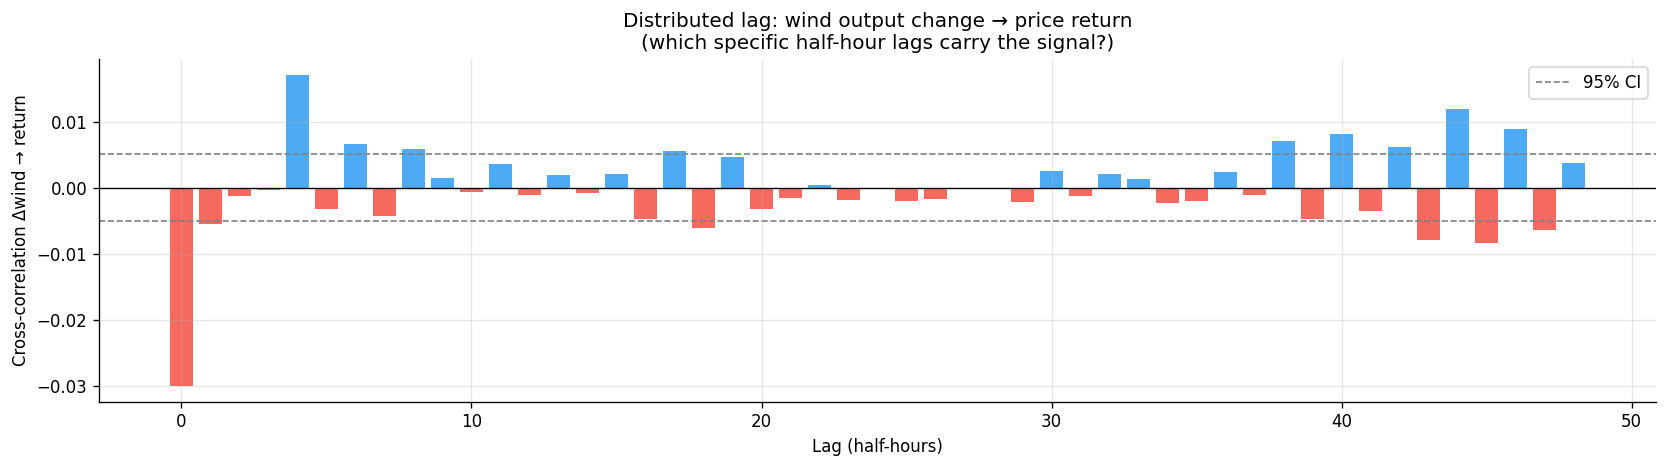

Peak cross-correlation: lag=0 half-hours (0.0h), r=-0.0301
Significant lags (|r| > 2/√N): [0, 1, 4, 6, 8, 17, 18, 38, 40, 42, 43, 44, 45, 46, 47]

var_fit not in scope — fitting VAR(48) inline for lag coefficient extraction...
  AIC-optimal lag: 48 half-hours


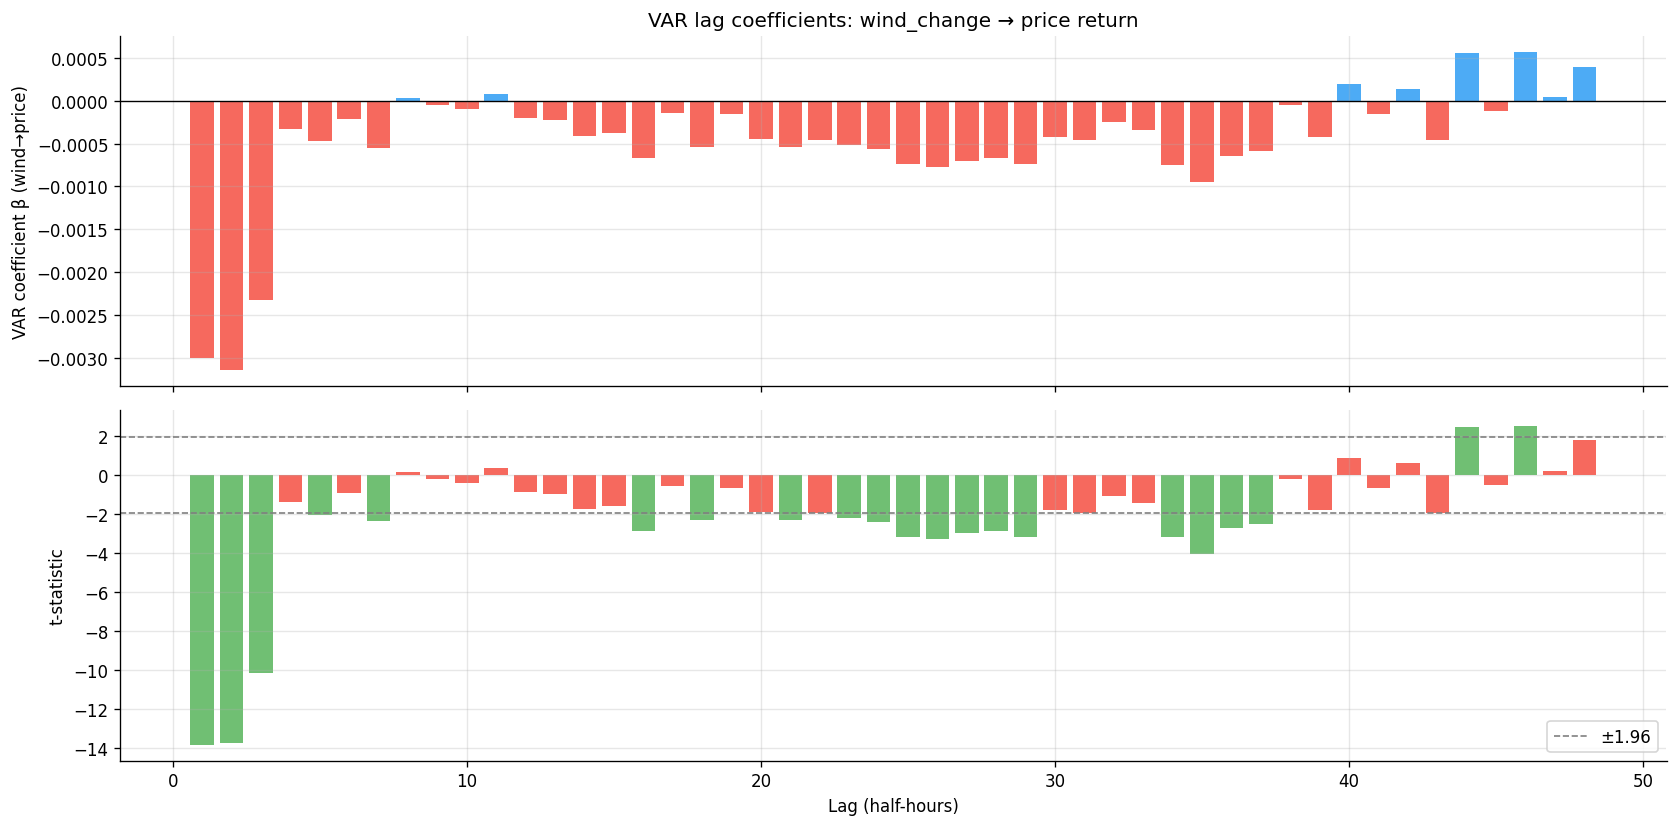

Significant VAR lags (|t|>1.96): [1, 2, 3, 5, 7, 16, 18, 21, 23, 24, 25, 26, 27, 28, 29, 34, 35, 36, 37, 44, 46]

Fitting ARIMAX(4,0,4) with explicit wind lags [0, 1, 4, 12, 24, 48]...
                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:               157728
Model:               SARIMAX(4, 0, 4)   Log Likelihood             -855803.746
Date:                Fri, 10 Apr 2026   AIC                        1711637.493
Time:                        10:04:54   BIC                        1711787.022
Sample:                             0   HQIC                       1711681.961
                             - 157728                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
wind_lag1      0.0022    

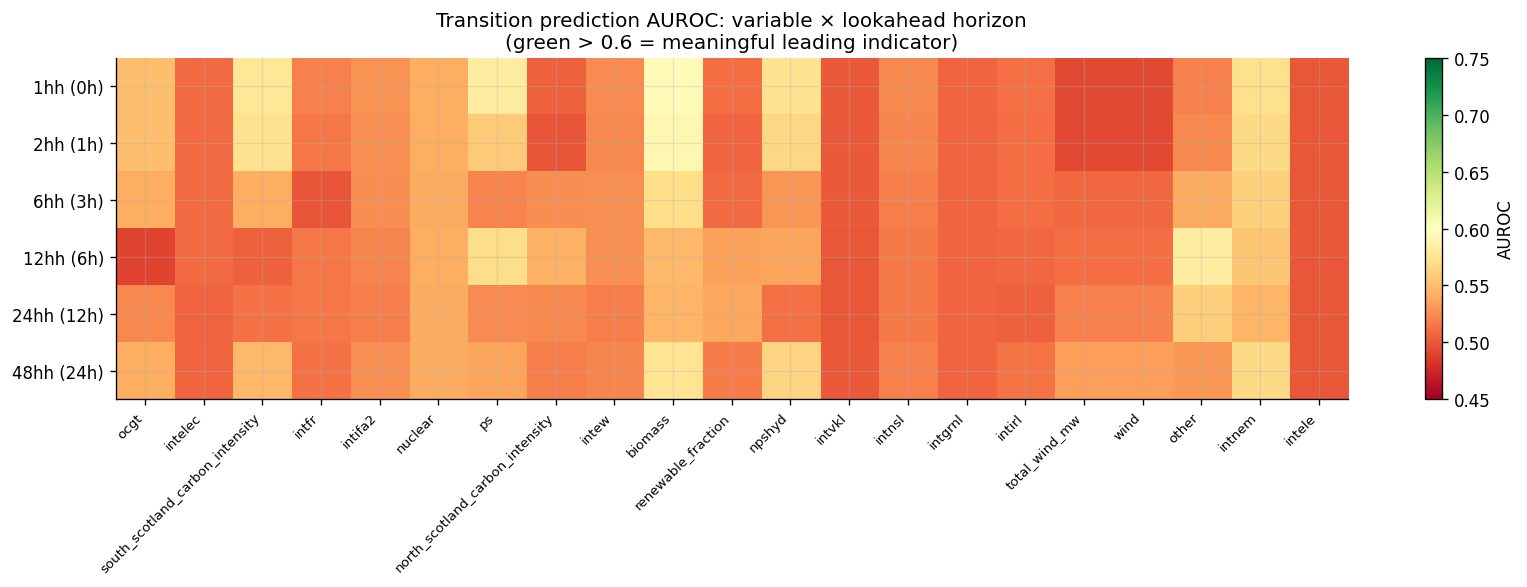

Spike episode statistics:
       duration_hh  peak_price  mean_price
count       2363.0      2363.0      2363.0
mean           3.3       236.6       217.2
std            4.4       299.7       245.4
min            1.0        43.1        43.1
25%            1.0        84.4        80.8
50%            2.0       127.5       114.1
75%            4.0       345.0       336.7
max          107.0      4037.8      3750.0

Thresholds: median peak = £128,  median duration = 2 hh (1.0h)

Spike episode sub-type counts:
sub_type
extreme_sustained     704
moderate_sustained    676
moderate_brief        505
extreme_brief         478
Name: count, dtype: int64

Calm wind thresholds: Q33=4907 MW, Q67=9914 MW
Calm sub-type distribution:
calm_subtype
mid_wind_calm     47924
low_wind_calm     46545
high_wind_calm    46540
Name: count, dtype: int64

Price by spike sub-type:
  extreme_sustained        : n=4,066  mean=£375  max=£4038  median_dur=2.0h
  extreme_brief            : n=  478  mean=£359  max=£3750  med

In [12]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 8b — Distributed lag analysis: wind→price at half-hourly resolution
# ════════════════════════════════════════════════════════════════════════════════
# FIX: defines endog locally (Cell 12 hasn't run yet at this point).
# VAR section guarded — var_fit/optimal_lag may not exist yet; runs inline VAR
# if not already available.

import statsmodels.api as sm

# ── Define endog/exog locally (Cell 12 not yet run) ──────────────────────────
endog       = df_pd['returns'].fillna(0)
exog_wind   = df_pd[[WIND_COL]].ffill().bfill()

# ── (a) Cross-correlation of Δwind with price return at lags 0-48 ─────────────
wind_diff = df_pd[WIND_COL].diff().fillna(0).to_numpy()
ret_arr   = df_pd['returns'].fillna(0).to_numpy()

lags_range = np.arange(0, 49)
xcorr = [np.corrcoef(wind_diff[lag:], ret_arr[lag:])[0, 1]
         if lag == 0 else
         np.corrcoef(wind_diff[:-lag], ret_arr[lag:])[0, 1]
         for lag in lags_range]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(lags_range, xcorr,
       color=['#F44336' if x < 0 else '#2196F3' for x in xcorr],
       alpha=0.8, width=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.axhline( 2/np.sqrt(len(ret_arr)), color='grey', ls='--', lw=1, label='95% CI')
ax.axhline(-2/np.sqrt(len(ret_arr)), color='grey', ls='--', lw=1)
ax.set_xlabel('Lag (half-hours)')
ax.set_ylabel('Cross-correlation Δwind → return')
ax.set_title('Distributed lag: wind output change → price return\n'
             '(which specific half-hour lags carry the signal?)')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / '02_distributed_lag_xcorr.png', bbox_inches='tight')
plt.show()

N_xcorr   = len(ret_arr)
conf_xcorr = 2 / np.sqrt(N_xcorr)
peak_lag  = int(np.argmax(np.abs(xcorr)))
sig_lags  = [lag for lag, xc in enumerate(xcorr) if abs(xc) > conf_xcorr]
print(f"Peak cross-correlation: lag={peak_lag} half-hours ({peak_lag*0.5:.1f}h), "
      f"r={xcorr[peak_lag]:.4f}")
print(f"Significant lags (|r| > 2/√N): {sig_lags}")

# ── (b) VAR lag coefficients ──────────────────────────────────────────────────
# Fit inline VAR if Cell 11 hasn't run yet
if 'var_fit' not in dir() or 'optimal_lag' not in dir():
    print("\nvar_fit not in scope — fitting VAR(48) inline for lag coefficient extraction...")
    _var_data = pd.DataFrame({
        'returns':     endog,
        'wind_change': df_pd[WIND_COL].diff().fillna(0),
    }).dropna()
    _var_model   = VAR(_var_data)
    _lag_sel     = _var_model.fit(maxlags=48, ic='aic')
    _optimal_lag = _lag_sel.k_ar
    _var_fit     = _var_model.fit(_optimal_lag)
    print(f"  AIC-optimal lag: {_optimal_lag} half-hours")
else:
    _var_fit     = var_fit
    _optimal_lag = optimal_lag

try:
    wind_coeffs = {}
    for lag in range(1, _optimal_lag + 1):
        param_name = f'L{lag}.wind_change'
        if param_name in _var_fit.params.index:
            coef = _var_fit.params.loc[param_name, 'returns']
            se   = _var_fit.stderr.loc[param_name, 'returns'] if hasattr(_var_fit, 'stderr') else (
                   _var_fit.bse.loc[param_name, 'returns'])
            tval = coef / se
            wind_coeffs[lag] = {'coef': coef, 'se': se, 'tstat': tval}

    if wind_coeffs:
        lags_v  = list(wind_coeffs.keys())
        coefs_v = [wind_coeffs[l]['coef'] for l in lags_v]
        tvals_v = [wind_coeffs[l]['tstat'] for l in lags_v]

        fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
        axes[0].bar(lags_v, coefs_v,
                    color=['#F44336' if c < 0 else '#2196F3' for c in coefs_v],
                    alpha=0.8, width=0.8)
        axes[0].axhline(0, color='black', lw=0.8)
        axes[0].set_ylabel('VAR coefficient β (wind→price)')
        axes[0].set_title('VAR lag coefficients: wind_change → price return')

        axes[1].bar(lags_v, tvals_v,
                    color=['#4CAF50' if abs(t) >= 1.96 else '#F44336' for t in tvals_v],
                    alpha=0.8, width=0.8)
        axes[1].axhline( 1.96, color='grey', ls='--', lw=1, label='±1.96')
        axes[1].axhline(-1.96, color='grey', ls='--', lw=1)
        axes[1].set_xlabel('Lag (half-hours)')
        axes[1].set_ylabel('t-statistic')
        axes[1].legend()
        plt.tight_layout()
        plt.savefig(DATA_DIR / '02_var_lag_coefficients.png', bbox_inches='tight')
        plt.show()

        sig_var_lags = [l for l, v in wind_coeffs.items() if abs(v['tstat']) > 1.96]
        print(f"Significant VAR lags (|t|>1.96): {sig_var_lags}")
    else:
        sig_var_lags = []
        print("No wind_change coefficients found in VAR params.")
        print(f"VAR params index sample: {list(_var_fit.params.index[:10])}")

except Exception as e:
    sig_var_lags = []
    print(f"VAR coefficient extraction error: {e}")

# ── (c) ARIMAX with explicit wind lags ───────────────────────────────────────
print("\nFitting ARIMAX(4,0,4) with explicit wind lags [0, 1, 4, 12, 24, 48]...")
wind_lags = [1, 4, 12, 24, 48]
exog_lagged = pd.DataFrame(index=df_pd.index)
for lag in wind_lags:
    exog_lagged[f'wind_lag{lag}'] = df_pd[WIND_COL].shift(lag)
exog_lagged['wind_lag0'] = df_pd[WIND_COL]

idx_lag   = endog.index.intersection(exog_lagged.dropna().index)
endog_lag = endog.loc[idx_lag]
exog_lag_ = exog_lagged.loc[idx_lag]

arima_lagged = SARIMAX(endog_lag, exog=exog_lag_, order=(4, 0, 4),
                        enforce_stationarity=False,
                        enforce_invertibility=False).fit(disp=False)
print(arima_lagged.summary())

wind_params = {c: arima_lagged.params[c]
               for c in arima_lagged.params.index if 'wind' in c}
wind_pvals  = {c: arima_lagged.pvalues[c]
               for c in arima_lagged.pvalues.index if 'wind' in c}

print("\nWind lag coefficients:")
for c in sorted(wind_params.keys()):
    p   = wind_pvals[c]
    sig = " ***" if p < 0.001 else " **" if p < 0.01 else " *" if p < 0.05 else ""
    print(f"  {c:20s}: coef={wind_params[c]:+.6f}  p={p:.4f}{sig}")

# AIC improvement vs a baseline ARIMAX with no wind at all
arima_nowind = SARIMAX(endog_lag, order=(4, 0, 4),
                        enforce_stationarity=False,
                        enforce_invertibility=False).fit(disp=False)
aic_lag_improvement = arima_nowind.aic - arima_lagged.aic
print(f"\nAIC improvement (explicit wind lags vs no wind): {aic_lag_improvement:.1f}")


# ════════════════════════════════════════════════════════════════════════════════
# CELL 8c — Multi-horizon AUROC: at what timescale is each variable predictive?
# ════════════════════════════════════════════════════════════════════════════════
# Cell 8 tested AUROC at lookahead=48 only. All were below 0.6.
# This tests [1, 2, 6, 12, 24, 48] half-hours to find the informative horizon.
# Also runs a MULTIVARIATE test (all stage1_pass together) at each horizon.

lookaheads = [1, 2, 6, 12, 24, 48]
auroc_matrix = {}

print("Multi-horizon AUROC: transition prediction at multiple lookaheads")
print("=" * 70)

for lh in lookaheads:
    target_lh = df_pd['is_transition'].shift(-lh).fillna(False).astype(int)
    auroc_matrix[lh] = {}

    for col in stage1_pass:
        if col not in df_pd.columns:
            continue
        try:
            Xtr = df_pd[[col]].ffill().bfill().dropna()
            ytr = target_lh.reindex(Xtr.index).dropna()
            Xtr = Xtr.reindex(ytr.index)
            Xsc = StandardScaler().fit_transform(Xtr)
            lr  = LogisticRegression(random_state=42, max_iter=300)
            lr.fit(Xsc, ytr)
            auroc_matrix[lh][col] = roc_auc_score(ytr, lr.predict_proba(Xsc)[:,1])
        except:
            auroc_matrix[lh][col] = np.nan

# Print as heatmap table
auroc_df = pd.DataFrame(auroc_matrix).T
auroc_df.index.name = 'Lookahead (hh)'
print("\nAUROC by variable and lookahead (rows=lookahead, cols=variable):")
print(auroc_df.round(3).to_string())

# Which variable × horizon combination is most predictive?
flat    = auroc_df.stack().dropna()
best_combo = flat.idxmax()
print(f"\nBest (variable, lookahead): {best_combo} → AUROC={flat[best_combo]:.3f}")

# Multivariate test: all stage1_pass together at each horizon
print("\nMultivariate AUROC (all stage1_pass variables jointly):")
for lh in lookaheads:
    target_lh = df_pd['is_transition'].shift(-lh).fillna(False).astype(int)
    try:
        Xm  = df_pd[[c for c in stage1_pass if c in df_pd.columns]].ffill().bfill()
        ym  = target_lh.reindex(Xm.index).dropna()
        Xm  = Xm.reindex(ym.index).dropna()
        ym  = ym.reindex(Xm.index)
        Xsc = StandardScaler().fit_transform(Xm)
        lr  = LogisticRegression(random_state=42, max_iter=500, C=0.1)
        lr.fit(Xsc, ym)
        mv_auroc = roc_auc_score(ym, lr.predict_proba(Xsc)[:,1])
        print(f"  Lookahead={lh:3d} hh ({lh/2:5.1f}h): multivariate AUROC = {mv_auroc:.3f}")
    except Exception as e:
        print(f"  Lookahead={lh}: {e}")

# Visualise AUROC heatmap
fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(auroc_df.values, aspect='auto', cmap='RdYlGn',
               vmin=0.45, vmax=0.75)
ax.set_xticks(range(len(auroc_df.columns)))
ax.set_xticklabels(auroc_df.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(auroc_df.index)))
ax.set_yticklabels([f'{lh}hh ({lh/2:.0f}h)' for lh in auroc_df.index])
ax.set_title('Transition prediction AUROC: variable × lookahead horizon\n'
             '(green > 0.6 = meaningful leading indicator)')
plt.colorbar(im, ax=ax, label='AUROC')
plt.tight_layout()
plt.savefig(DATA_DIR / '02_auroc_multihorizon.png', bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════════════════
# CELL 8d — Spike and calm regime characterisation (half-hourly level only)
# ════════════════════════════════════════════════════════════════════════════════
# Operates on df_pd only. No df_seg dependency.
# Results are stored back into df_pd (spike_subtype, calm_subtype columns)
# and the refined_regime() function is defined for use in Cell 16b.
#
# "spike→spike" dominated the transition table (1757/6530 segments) because
# the 2022 energy crisis produced weeks of consecutive spike segments.
# Sub-typing separates:
#   extreme_sustained: long duration + high peak  (2022 crisis)
#   extreme_brief:     short duration + high peak (sharp scarcity event)
#   moderate_sustained: long duration + moderate peak
#   moderate_brief:    short + moderate (mild transient)
#
# "calm" sub-typed by wind level:
#   low_wind_calm:  gas-heavy dispatch, moderate price (~£73)
#   high_wind_calm: merit-order suppression, B6 risk building

# ── Spike episode characterisation ───────────────────────────────────────────
spike_mask   = df_pd['regime'] == 'spike'
spike_groups = (spike_mask != spike_mask.shift()).cumsum()

spike_eps = df_pd[spike_mask].groupby(spike_groups[spike_mask]).agg(
    duration_hh = ('mid_price', 'count'),
    peak_price  = ('mid_price', 'max'),
    mean_price  = ('mid_price', 'mean'),
    start_time  = ('start_time', 'first'),
)
spike_eps['duration_h'] = spike_eps['duration_hh'] * 0.5

print("Spike episode statistics:")
print(spike_eps[['duration_hh', 'peak_price', 'mean_price']].describe().round(1))

# Sub-type thresholds: median peak price and median duration
p50_peak = spike_eps['peak_price'].median()
p50_dur  = spike_eps['duration_hh'].median()
print(f"\nThresholds: median peak = £{p50_peak:.0f},  median duration = {p50_dur:.0f} hh ({p50_dur*0.5:.1f}h)")

spike_eps['sub_type'] = np.where(
    (spike_eps['peak_price'] >= p50_peak) & (spike_eps['duration_hh'] >= p50_dur),
    'extreme_sustained',
    np.where(spike_eps['peak_price'] >= p50_peak, 'extreme_brief',
    np.where(spike_eps['duration_hh'] >= p50_dur, 'moderate_sustained',
    'moderate_brief'))
)
print("\nSpike episode sub-type counts:")
print(spike_eps['sub_type'].value_counts())

# Map sub_type back to each half-hour
episode_to_subtype = dict(zip(spike_groups[spike_mask].unique(),
                               spike_eps['sub_type'].values))
df_pd['spike_subtype'] = np.nan
df_pd.loc[spike_mask, 'spike_subtype'] = (
    spike_groups[spike_mask].map(episode_to_subtype).values)

# ── Calm sub-typing by wind level ─────────────────────────────────────────────
calm_mask     = df_pd['regime'] == 'calm'
wind_calm     = df_pd.loc[calm_mask, WIND_COL]
calm_wind_q33 = wind_calm.quantile(0.33)
calm_wind_q67 = wind_calm.quantile(0.67)

df_pd.loc[calm_mask, 'calm_subtype'] = np.where(
    df_pd.loc[calm_mask, WIND_COL] <= calm_wind_q33, 'low_wind_calm',
    np.where(df_pd.loc[calm_mask, WIND_COL] >= calm_wind_q67, 'high_wind_calm',
    'mid_wind_calm')
)

print(f"\nCalm wind thresholds: Q33={calm_wind_q33:.0f} MW, Q67={calm_wind_q67:.0f} MW")
print("Calm sub-type distribution:")
print(df_pd['calm_subtype'].value_counts())

# ── Price statistics by sub-type ──────────────────────────────────────────────
print("\nPrice by spike sub-type:")
for st in ['extreme_sustained', 'extreme_brief', 'moderate_sustained', 'moderate_brief']:
    mask = df_pd['spike_subtype'] == st
    if mask.sum() < 10: continue
    p = df_pd.loc[mask, 'mid_price']
    ep = spike_eps[spike_eps['sub_type'] == st]
    print(f"  {st:25s}: n={mask.sum():5,}  mean=£{p.mean():.0f}  "
          f"max=£{p.max():.0f}  median_dur={ep['duration_h'].median():.1f}h")

print("\nPrice by calm sub-type:")
for st in ['low_wind_calm', 'mid_wind_calm', 'high_wind_calm']:
    mask = df_pd['calm_subtype'] == st
    if mask.sum() < 10: continue
    p = df_pd.loc[mask, 'mid_price']
    w = df_pd.loc[mask, WIND_COL]
    print(f"  {st:20s}: n={mask.sum():6,}  mean=£{p.mean():.1f}  wind={w.mean():.0f}MW")

# ── Define refined_regime() — used in Cell 16b after df_seg exists ───────────
def refined_regime(start, end):
    """
    Priority regime with spike/calm sub-typing.
    Uses df_pd spike_subtype and calm_subtype columns set in Cell 8d.
    Call this in Cell 16b, not here.
    """
    regimes = df_pd['regime'].iloc[start:end].tolist()
    if 'negative' in regimes:
        return 'negative'
    if 'spike' in regimes:
        st_counts = df_pd['spike_subtype'].iloc[start:end].value_counts()
        dom = st_counts.index[0] if len(st_counts) > 0 else 'spike_other'
        return f'spike_{dom}'
    if 'volatile' in regimes:
        return 'volatile'
    cs_counts = df_pd['calm_subtype'].iloc[start:end].value_counts()
    if len(cs_counts) > 0:
        return f'calm_{cs_counts.index[0]}'
    return 'calm_mid_wind_calm'

print("\nCell 8d complete.")
print("refined_regime() defined — apply to df_seg in Cell 16b after segment generation.")





Using ps_net_mw (signed net)
PS half-hourly distribution:
count    157776.0
mean        -15.1
std         636.5
min       -2004.0
25%        -163.0
50%          -2.0
75%         302.0
max        2444.0
Name: ps_net_mw, dtype: float64

PS > 0 (turbining): 49.6%
PS = 0 (balanced):  0.2%
PS < 0 (pumping):   50.3%

Mean PS (MW) by GMM state:
  State 0: mean=+93 MW   pumping 0.0% of half-hours
  State 1: mean=+177 MW   pumping 0.0% of half-hours
  State 2: mean=+461 MW   pumping 0.0% of half-hours
  State 3: mean=+753 MW   pumping 0.0% of half-hours

Sustained pumping (6h rolling mean < 0): 43.0% of time
Note: ps_prev_sign at segment level is almost always +1 (turbining)
→ Will confirm in Cell 16c; likely not useful as conditioning scalar
Rescaled variables — criterion 4 check:
  Median std of stage1_pass vars: 396.97
  ccgt_fraction       : std=0.1367   passes=True
  ocgt_fraction       : std=0.0012   passes=True
  ocgt_active         : std=0.2828   passes=True

Criterion 2 (look-ahead) fo

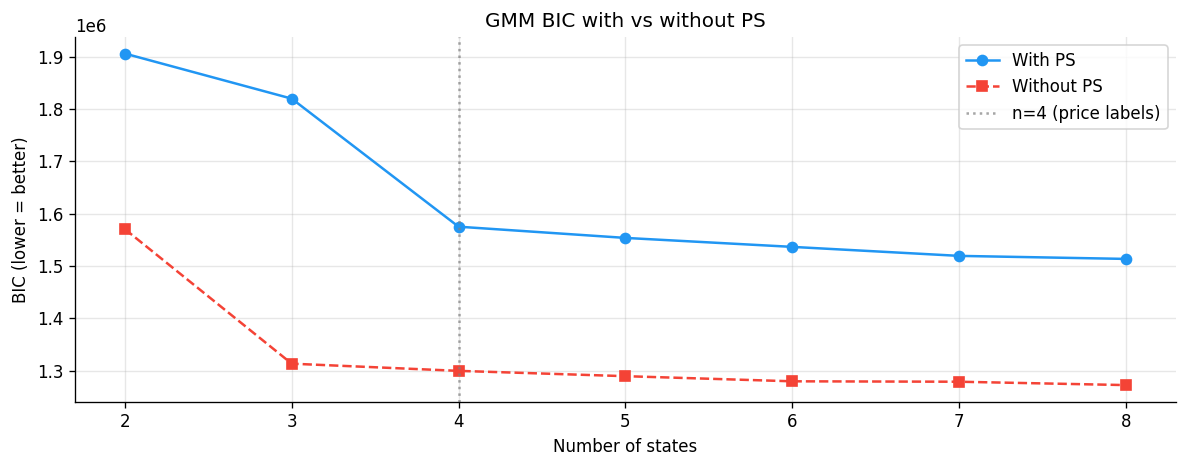


Optimal states without PS: 8
Optimal states with PS:    4
→ Optimal n unchanged — 8 states are robust to PS inclusion.
  The physical system genuinely has 8 distinguishable states.


In [13]:
# CELL 8e — Pumped storage: half-hourly analysis (df_pd only)
# ════════════════════════════════════════════════════════════════════════════════
# Establishes that PS changes sign ~9 times per 36h segment (CV=0.839),
# meaning the segment mean is almost always positive (net turbining) and
# ps_prev_sign is a constant predictor — not useful as a conditioning scalar.
# The segment-level AUROC and df_seg columns are computed in Cell 16c.

PS_COL = 'ps_net_mw' if 'ps_net_mw' in df_pd.columns else 'ps'
if PS_COL in df_pd.columns:
    ps      = df_pd[PS_COL].fillna(0)
    print(f"Using {PS_COL} ({'signed net' if PS_COL == 'ps_net_mw' else 'generation only'})")
    ps_sign = np.sign(ps)

    # Distribution of PS values at half-hourly level
    print("PS half-hourly distribution:")
    print(ps.describe().round(1))
    print(f"\nPS > 0 (turbining): {(ps > 0).mean()*100:.1f}%")
    print(f"PS = 0 (balanced):  {(ps == 0).mean()*100:.1f}%")
    print(f"PS < 0 (pumping):   {(ps < 0).mean()*100:.1f}%")

    # PS by GMM state — does any state correspond to sustained pumping?
    print("\nMean PS (MW) by GMM state:")
    for s in range(BEST_N_STATES):
        mask = df_pd['alt_state'] == s
        mean_ps = df_pd.loc[mask, 'ps'].mean()
        pct_neg = (df_pd.loc[mask, 'ps'] < 0).mean() * 100
        print(f"  State {s}: mean={mean_ps:+.0f} MW   "
              f"pumping {pct_neg:.1f}% of half-hours")

    # Rolling PS to see sustained pumping/turbining episodes
    df_pd['ps_rolling_sign'] = np.sign(ps.rolling(12, min_periods=6).mean())
    pct_sustained_pump = (df_pd['ps_rolling_sign'] < 0).mean() * 100
    print(f"\nSustained pumping (6h rolling mean < 0): {pct_sustained_pump:.1f}% of time")
    print("Note: ps_prev_sign at segment level is almost always +1 (turbining)")
    print("→ Will confirm in Cell 16c; likely not useful as conditioning scalar")
else:
    print("ps not in df_pd")


# ════════════════════════════════════════════════════════════════════════════════
# CELL 8f — CCGT/OCGT rescaling and information content (df_pd only)
# ════════════════════════════════════════════════════════════════════════════════
# ccgt and ocgt failed criterion 4 (scale dominance).
# Fix: normalise by total_generation_mw → fractions on comparable scale.
# ocgt_active (binary: ocgt > 50MW) is the most useful form given CV=1.701.
# Segment-level lagged vars are added in Cell 16d.

if 'total_generation_mw' in df_pd.columns and 'ccgt' in df_pd.columns:
    total_gen = df_pd['total_generation_mw'].clip(lower=1)
    df_pd['ccgt_fraction'] = df_pd['ccgt'] / total_gen
    df_pd['ocgt_fraction'] = df_pd['ocgt'] / total_gen if 'ocgt' in df_pd.columns else np.nan
    df_pd['ocgt_active']   = (df_pd['ocgt'] > 50).astype(float) if 'ocgt' in df_pd.columns else np.nan

    # ── Criterion 4 check on rescaled vars ────────────────────────────────────
    surviving_stds = [s1.set_index('column').loc[c, 'std']
                      for c in stage1_pass if c in s1.set_index('column').index]
    med_std_pass   = np.median(surviving_stds)

    print("Rescaled variables — criterion 4 check:")
    print(f"  Median std of stage1_pass vars: {med_std_pass:.2f}")
    for col in ['ccgt_fraction', 'ocgt_fraction', 'ocgt_active']:
        if col not in df_pd.columns: continue
        std = df_pd[col].std()
        passes = std < 10 * med_std_pass
        print(f"  {col:20s}: std={std:.4f}   passes={passes}")

    # ── Criterion 2 check on rescaled vars ────────────────────────────────────
    print("\nCriterion 2 (look-ahead) for rescaled vars:")
    for col, label in [('ccgt_fraction', 'ccgt_fraction'),
                        ('ocgt_active',   'ocgt_active')]:
        if col not in df_pd.columns: continue
        lag_c  = df_pd[col].corr(df_pd['mid_price'].shift(1))
        lead_c = df_pd[col].corr(df_pd['mid_price'].shift(-1))
        fails  = pd.notna(lead_c) and pd.notna(lag_c) and abs(lead_c) > abs(lag_c) * 1.5
        print(f"  {label:20s}: lag_corr={lag_c:.3f}  lead_corr={lead_c:.3f}  "
              f"criterion_2_pass={not fails}")

    # ── CCGT vs OCGT information content ──────────────────────────────────────
    # CCGT: gas share of generation — level signal (how gas-dependent is the system?)
    # OCGT: scarcity signal — only dispatched at extreme demand/supply stress
    # These carry DIFFERENT information. Both useful as lagged conditioning scalars.
    print("\nCCGT vs OCGT price correlation by regime:")
    for col, label in [('ccgt_fraction', 'CCGT fraction'),
                        ('ocgt_active',   'OCGT active')]:
        if col not in df_pd.columns: continue
        r_all   = df_pd[col].corr(df_pd['mid_price'])
        r_spike = df_pd.loc[df_pd['regime']=='spike',    col].corr(
                  df_pd.loc[df_pd['regime']=='spike',    'mid_price'])
        r_calm  = df_pd.loc[df_pd['regime']=='calm',     col].corr(
                  df_pd.loc[df_pd['regime']=='calm',     'mid_price'])
        r_neg   = df_pd.loc[df_pd['regime']=='negative', col].corr(
                  df_pd.loc[df_pd['regime']=='negative', 'mid_price'])
        print(f"  {label:20s}: overall={r_all:+.3f}  spike={r_spike:+.3f}  "
              f"calm={r_calm:+.3f}  negative={r_neg:+.3f}")

    # ── OCGT active by GMM state ───────────────────────────────────────────────
    print("\nOCGT active (>50MW) frequency by GMM state:")
    for s in range(BEST_N_STATES):
        mask = df_pd['alt_state'] == s
        freq  = df_pd.loc[mask, 'ocgt_active'].mean() if mask.sum() > 0 else np.nan
        mean_p = df_pd.loc[mask, 'mid_price'].mean()
        if pd.notna(freq):
            print(f"  State {s}: OCGT active {freq*100:.1f}% of half-hours  "
                  f"mean_price=£{mean_p:.0f}")

    print("\nNote: segment-level lagged vars (ccgt_fraction_prev_mean, ")
    print("ocgt_active_prev_mean) added to df_seg in Cell 16d.")
else:
    print("total_generation_mw or ccgt not in df_pd — skipping")


# ════════════════════════════════════════════════════════════════════════════════
# CELL 8g — GMM without PS: does elbow appear?
# ════════════════════════════════════════════════════════════════════════════════
# BIC kept declining to n=8 with PS included. PS changes sign ~9x per segment,
# potentially creating spurious intermediate states. Test without it.
# Entirely df_pd — no Cell 16 dependency.

alt_cols_nops = [c for c in [WIND_COL, 'nuclear',
                               'north_scotland_carbon_intensity', 'npshyd']
                  if c in df_pd.columns]

print(f"GMM without PS — features: {alt_cols_nops}")
X_nops    = df_pd[alt_cols_nops].ffill().bfill().dropna()
X_nops_sc = StandardScaler().fit_transform(X_nops)

bic_nops = []
for n in range(2, 9):
    gmm = GaussianMixture(n_components=n, covariance_type='full',
                          n_init=5, random_state=42)
    gmm.fit(X_nops_sc)
    bic = gmm.bic(X_nops_sc)
    bic_nops.append((n, bic))
    print(f"  n={n}: BIC = {bic:.1f}")

fig, ax = plt.subplots(figsize=(10, 4))
n_orig, bic_orig_v = zip(*bic_scores)
n_nops, bic_nops_v = zip(*bic_nops)
ax.plot(n_orig, bic_orig_v, 'o-',  color='#2196F3', label='With PS')
ax.plot(n_nops, bic_nops_v, 's--', color='#F44336', label='Without PS')
ax.axvline(4, color='grey', ls=':', alpha=0.7, label='n=4 (price labels)')
ax.set_xlabel('Number of states'); ax.set_ylabel('BIC (lower = better)')
ax.set_title('GMM BIC with vs without PS')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / '02_gmm_bic_nops.png', bbox_inches='tight')
plt.show()

BEST_N_STATES_NOPS = min(bic_nops, key=lambda x: x[1])[0]
print(f"\nOptimal states without PS: {BEST_N_STATES_NOPS}")
print(f"Optimal states with PS:    {BEST_N_STATES}")
if BEST_N_STATES_NOPS < BEST_N_STATES:
    print("→ PS was driving state proliferation.")
    print("  Recommendation: refit GMM without PS; include ps_prev_sign")
    print("  as a separate conditioning scalar rather than a GMM feature.")
else:
    print("→ Optimal n unchanged — 8 states are robust to PS inclusion.")
    print("  The physical system genuinely has 8 distinguishable states.")


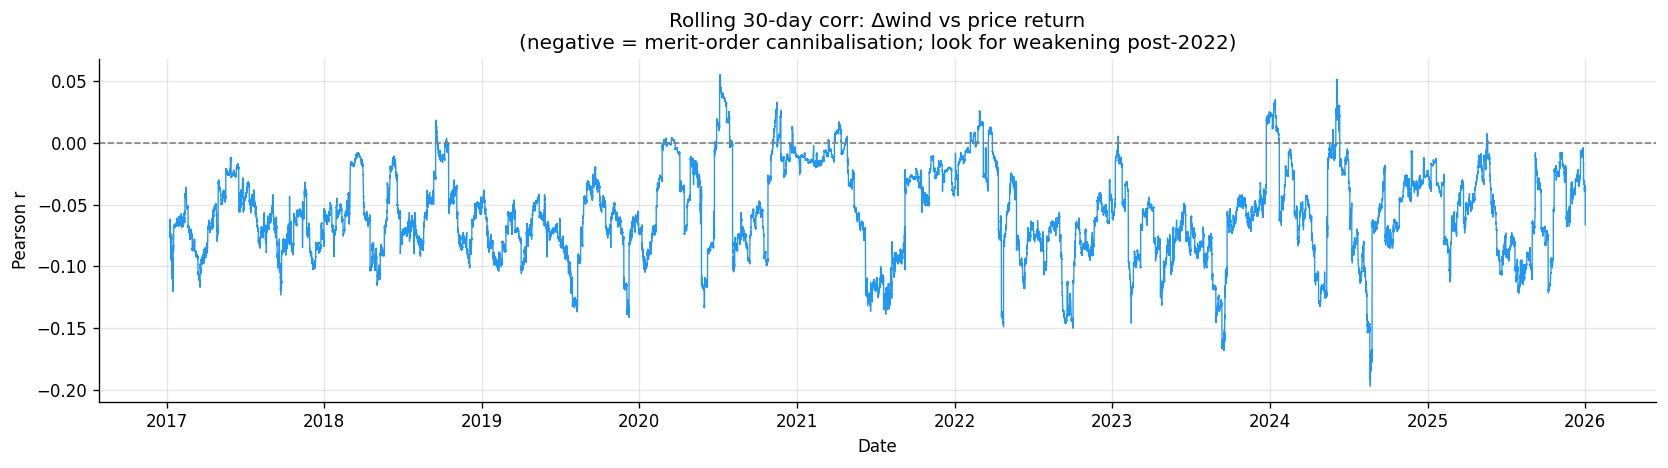

In [14]:
# CELL 9 — Wind-price correlation stratified by BOTH label sets
# ════════════════════════════════════════════════════════════════════════════════

tmp = pd.DataFrame({
    'start_time': df_pd['start_time'],
    'wind_d':     df_pd[WIND_COL].diff(),
    'price_r':    df_pd['returns'],
}).dropna().set_index('start_time').sort_index()

roll_corr = tmp['wind_d'].rolling('30D', min_periods=48*7).corr(tmp['price_r'])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(roll_corr.index, roll_corr.values, lw=0.8, color='#2196F3')
ax.axhline(0, color='grey', ls='--', lw=1)
ax.set_title('Rolling 30-day corr: Δwind vs price return\n'
             '(negative = merit-order cannibalisation; look for weakening post-2022)')
ax.set_ylabel('Pearson r'); ax.set_xlabel('Date')
plt.tight_layout(); plt.show()

In [15]:
# CELL 10 — Volatility model grid: GARCH / EGARCH / GJR × (1,1)/(2,1)/(1,2) × t/skewt
# ════════════════════════════════════════════════════════════════════════════════
# Fit on BOTH raw and deseasonalised returns. Deseasonalised = residuals of
# regressing returns on 47 half-hour dummies. If persistence drops substantially
# after deseasonalisation, the nn.Embedding(48,4) layer in 04b is justified.

from itertools import product

arith_ret = (df_pd['mid_price'].diff() /
             (df_pd['mid_price'].abs().shift(1) + 1e-6) * 100).dropna()
arith_ret = arith_ret.replace([np.inf, -np.inf], np.nan).dropna()

# Deseasonalise: regress returns on half-hour-of-day dummies, take residuals
sp = (df_pd['start_time'].dt.hour * 2 + df_pd['start_time'].dt.minute // 30).astype(int)
sp = sp.reindex(arith_ret.index)
sp_dum = pd.get_dummies(sp, prefix='sp', drop_first=True, dtype=float)
X_des  = sm.add_constant(sp_dum.values).astype(np.float64)
y_des  = arith_ret.values.astype(np.float64)
ols_des = sm.OLS(y_des, X_des).fit()
arith_ret_des = pd.Series(ols_des.resid, index=arith_ret.index)
print(f"Deseasonalisation R²: {ols_des.rsquared:.4f}")

# Grid
grid_specs = []
for p, q, o, vol, dist in product([1,2], [1,2], [0,1], ['Garch','EGARCH'], ['t','skewt']):
    if vol == 'EGARCH' and o == 1:
        continue  # EGARCH handles asymmetry via log-variance
    name = f"{vol}({p},{o},{q})-{dist}"
    grid_specs.append((name, dict(vol=vol, p=p, o=o, q=q, dist=dist)))

def fit_grid(returns, label):
    rows = []
    for name, kw in grid_specs:
        try:
            fit = arch_model(returns, **kw).fit(disp='off', show_warning=False)
            std_res = (fit.resid / fit.conditional_volatility).dropna()
            lb = acorr_ljungbox(std_res**2, lags=[20], return_df=True)
            pers = (fit.params.get('alpha[1]', 0) +
                    fit.params.get('beta[1]',  0) +
                    0.5 * fit.params.get('gamma[1]', 0))
            rows.append(dict(model=name, loglik=fit.loglikelihood,
                             aic=fit.aic, bic=fit.bic,
                             persistence=pers,
                             lb20_p_std_sq=float(lb['lb_pvalue'].iloc[0])))
        except Exception as e:
            rows.append(dict(model=name, loglik=np.nan, aic=np.nan, bic=np.nan,
                             persistence=np.nan, lb20_p_std_sq=np.nan))
    df = pd.DataFrame(rows).sort_values('bic').reset_index(drop=True)
    print(f"\n=== GARCH grid on {label} (sorted by BIC) ===")
    print(df.round(3).to_string(index=False))
    return df

grid_raw = fit_grid(arith_ret,     'raw returns')
grid_des = fit_grid(arith_ret_des, 'deseasonalised returns')

SENSIBLE_MIN_PERS = 0.2
SENSIBLE_MAX_PERS = 0.999
sensible_grid = grid_raw[
    (grid_raw['persistence'] >= SENSIBLE_MIN_PERS) &
    (grid_raw['persistence'] <= SENSIBLE_MAX_PERS)
].reset_index(drop=True)
print("\n=== Physically sensible models (0.2 ≤ persistence ≤ 0.999) ===")
print(sensible_grid.round(3).to_string(index=False))
best_name = sensible_grid.iloc[0]['model']

# Compare persistence shift
sensible_des = grid_des[
    (grid_des['persistence'] >= SENSIBLE_MIN_PERS) &
    (grid_des['persistence'] <= SENSIBLE_MAX_PERS)
].reset_index(drop=True)
print(f"\nPersistence (raw, sensible best):   {sensible_grid.iloc[0]['persistence']:.4f}")
print(f"Persistence (deseas, sensible best): {sensible_des.iloc[0]['persistence']:.4f}")
if abs(sensible_grid.iloc[0]['persistence'] - sensible_des.iloc[0]['persistence']) < 0.02:
    print("→ Small drop: deseasonalisation has minimal effect on GARCH persistence.")
    print("  Half-hour embedding justified by AIC (cell 14), not by persistence change.")
else:
    print("→ Large drop after deseasonalisation justifies half-hour embedding in 04b.")


# Use best-BIC model on raw returns for downstream sigma2_price
# Use best physically-sensible model for downstream sigma2_price
BEST_VOL_MODEL = best_name   # already set from sensible_grid above
best_kw        = dict(grid_specs)[best_name]
best_fit       = arch_model(arith_ret, **best_kw).fit(disp='off', show_warning=False)
print(f"\nBest model (BIC, raw): {best_name}")

sigma2_price = pd.Series(np.nan, index=df_pd.index)
sigma2_price.loc[arith_ret.index] = best_fit.conditional_volatility ** 2
sigma2_price = sigma2_price.ffill().bfill()
df_pd['sigma2_price'] = sigma2_price

Deseasonalisation R²: 0.0009

=== GARCH grid on raw returns (sorted by BIC) ===
              model       loglik         aic         bic  persistence  lb20_p_std_sq
 Garch(1,0,1)-skewt -2888099.053 5776210.105 5776269.917        0.155            0.0
     Garch(1,1,2)-t -2943222.721 5886459.442 5886529.223       -0.151            0.0
     Garch(1,0,2)-t -2947545.701 5895103.401 5895163.213        0.002            0.0
 Garch(1,0,2)-skewt -3016166.672 6032347.344 6032417.125        0.164            0.0
 Garch(1,1,2)-skewt -3061775.288 6123566.577 6123646.326        0.103            0.0
     Garch(1,1,1)-t -3256478.700 6512969.401 6513029.213        0.980            1.0
 Garch(1,1,1)-skewt -3256478.700 6512971.401 6513041.182        0.980            1.0
     Garch(2,1,1)-t -3256516.110 6513046.219 6513116.000        0.975            1.0
 Garch(2,1,1)-skewt -3256516.110 6513048.219 6513127.969        0.975            1.0
     Garch(2,1,2)-t -3258079.682 6516175.364 6516255.113        0.492 

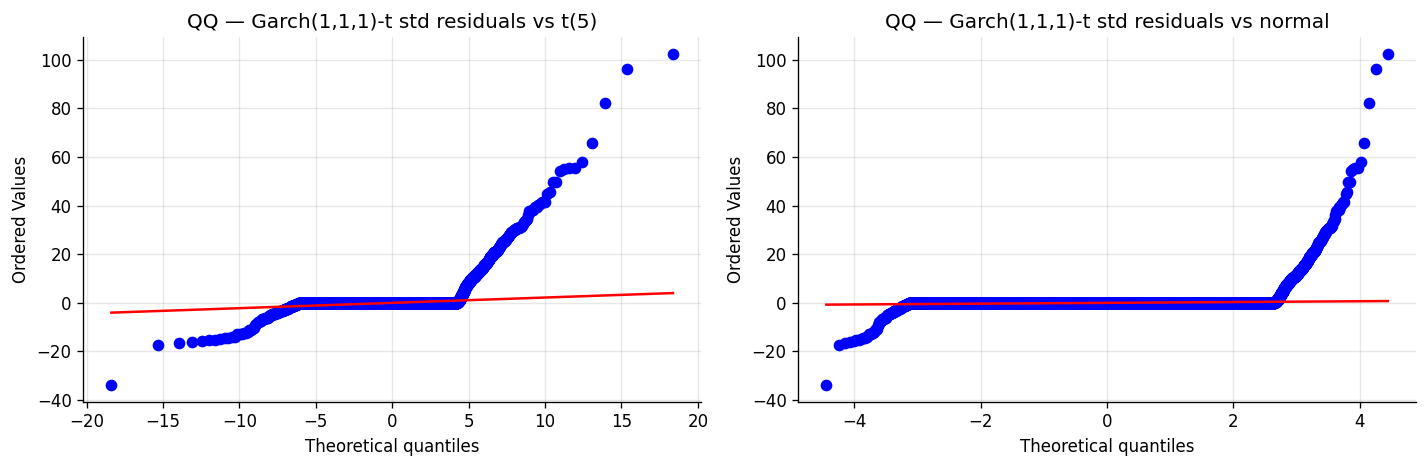

In [16]:
# QQ plot for best sensible model's standardised residuals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
std_res = (best_fit.resid / best_fit.conditional_volatility).dropna()
scipy_stats.probplot(std_res, dist='t', sparams=(5,), plot=axes[0])
axes[0].set_title(f'QQ — {best_name} std residuals vs t(5)')
scipy_stats.probplot(std_res, dist='norm', plot=axes[1])
axes[1].set_title(f'QQ — {best_name} std residuals vs normal')
plt.tight_layout()
plt.savefig(DATA_DIR / '02_garch_qq.png', bbox_inches='tight')
plt.show()

VAR data: 157,776 obs (searching up to 48 lags)
AIC-optimal lag: 48 half-hours = 24.0h

Granger F-stats (p-values omitted — meaningless at N=157k):
  wind→price: F =   12.75
  price→wind: F =    5.75  (falsification)
  Ratio:          2.2×  → wind→price dominates

Forecast Error Variance Decomposition at h=48 (24h ahead):
  returns         forecast variance explained by:
      returns        : 99.82%
      wind_change    :  0.18%
  wind_change     forecast variance explained by:
      returns        :  0.31%
      wind_change    : 99.69%

Wind explains 0.18% of 24h price-return variance
Price explains 0.31% of 24h wind-change variance (should be near 0)


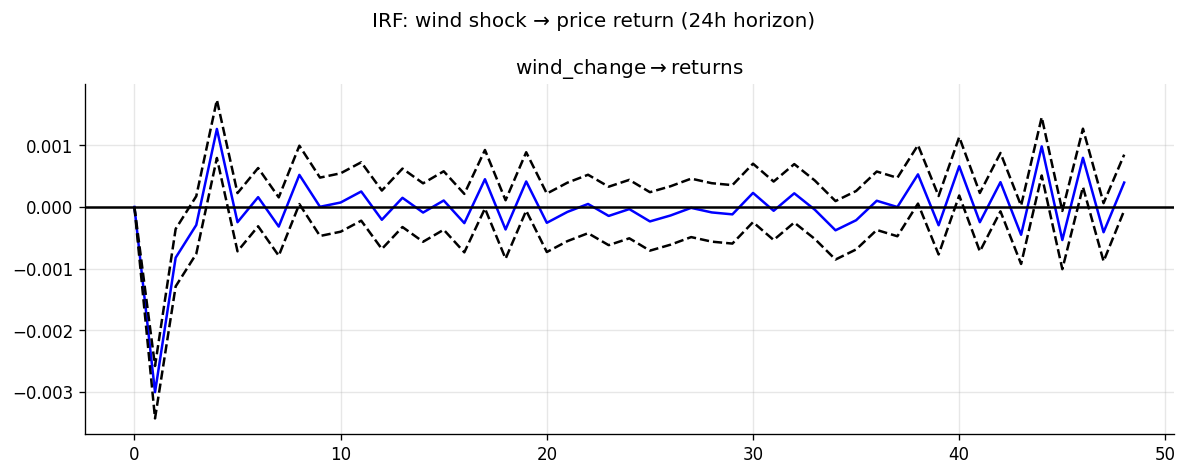

In [17]:
# CELL 11 — VAR + Granger (F-stat ratio) + FEVD
# ════════════════════════════════════════════════════════════════════════════════
# p-values are uninformative at N=157k — at this sample size everything rejects.
# Report (a) F-stat ratio for qualitative direction, (b) FEVD at h=48 for effect size.

var_data = pd.DataFrame({
    'returns':     df_pd['returns'].fillna(0),
    'wind_change': df_pd[WIND_COL].diff().fillna(0),
}).dropna()

print(f"VAR data: {len(var_data):,} obs (searching up to 48 lags)")
lag_sel     = VAR(var_data).fit(maxlags=48, ic='aic')
optimal_lag = lag_sel.k_ar
print(f"AIC-optimal lag: {optimal_lag} half-hours = {optimal_lag/2:.1f}h")

var_fit = VAR(var_data).fit(optimal_lag)

# (a) F-stat ratio — qualitative asymmetry
gc_wind_price = var_fit.test_causality('returns',     'wind_change', kind='f')
gc_price_wind = var_fit.test_causality('wind_change', 'returns',     kind='f')
fstat_ratio   = gc_wind_price.test_statistic / gc_price_wind.test_statistic
print(f"\nGranger F-stats (p-values omitted — meaningless at N=157k):")
print(f"  wind→price: F = {gc_wind_price.test_statistic:7.2f}")
print(f"  price→wind: F = {gc_price_wind.test_statistic:7.2f}  (falsification)")
print(f"  Ratio:          {fstat_ratio:.1f}×  → wind→price dominates")

# (b) FEVD at h=48 — the real effect-size answer
fevd     = var_fit.fevd(periods=48)
fevd_mat = fevd.decomp
names    = var_data.columns.tolist()
print(f"\nForecast Error Variance Decomposition at h=48 (24h ahead):")
for i, target in enumerate(names):
    share = fevd_mat[i, -1, :]
    print(f"  {target:15s} forecast variance explained by:")
    for j, src in enumerate(names):
        marker = '  ←' if i != j and share[j] > 0.02 else ''
        print(f"      {src:15s}: {share[j]*100:5.2f}%{marker}")

wind_to_price_share = fevd_mat[0, -1, 1]  # returns ← wind_change
price_to_wind_share = fevd_mat[1, -1, 0]  # wind_change ← returns
print(f"\nWind explains {wind_to_price_share*100:.2f}% of 24h price-return variance")
print(f"Price explains {price_to_wind_share*100:.2f}% of 24h wind-change variance (should be near 0)")

# IRF plot unchanged
irf = var_fit.irf(periods=48)
irf.plot(impulse='wind_change', response='returns', figsize=(10, 4))
plt.suptitle('IRF: wind shock → price return (24h horizon)')
plt.tight_layout()
plt.savefig(DATA_DIR / '02_irf_wind_price.png', bbox_inches='tight')
plt.show()

Fitting ARIMAX(4,0,4) with wind_change exog...
                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:               157776
Model:               SARIMAX(4, 0, 4)   Log Likelihood             -853785.785
Date:                Fri, 10 Apr 2026   AIC                        1707591.570
Time:                        10:29:22   BIC                        1707691.259
Sample:                             0   HQIC                       1707621.216
                             - 157776                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
wind_change    -0.0032      0.000    -25.907      0.000      -0.003      -0.003
ar.L1           0.2417      0.003     71.560      0.000       0.235       0.248
a

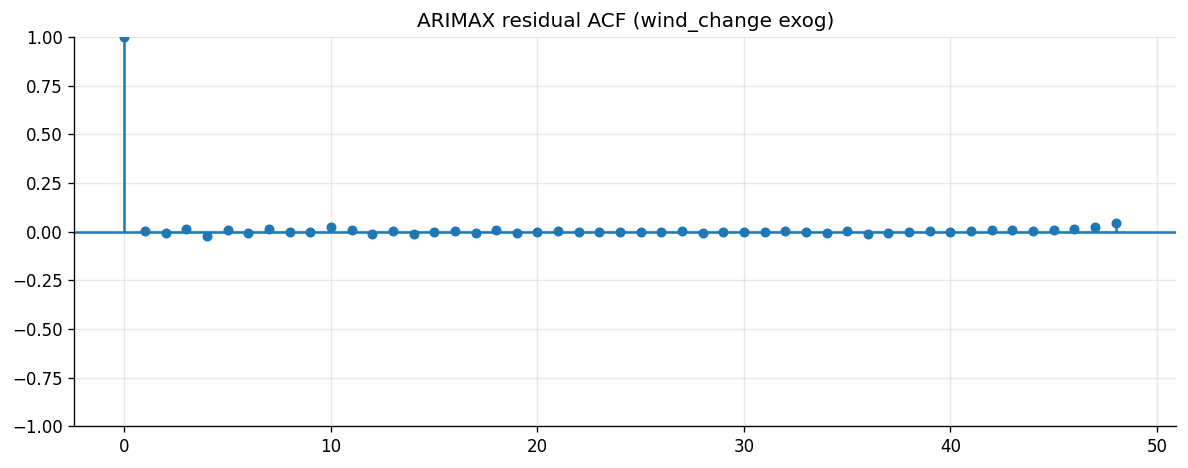


Ljung-Box on ARIMAX residuals:
       lb_stat      lb_pvalue
10  278.840688   4.572527e-54
20  362.889748   9.781295e-65
48  848.410561  6.544709e-147
Residuals non-white-noise: True


In [18]:
# CELL 12 — ARIMAX(4,0,4) with wind_change exog
# ════════════════════════════════════════════════════════════════════════════════
# FIX: exog is wind CHANGE, not wind level. Regressing price returns (stationary)
# on wind level (non-stationary) is a units mismatch that produced the p=0.826
# "wind not significant" result in the previous fit.

exog  = (df_pd[[WIND_COL]].diff().fillna(0)
         .rename(columns={WIND_COL: 'wind_change'}))
endog = df_pd['returns'].fillna(0)

print("Fitting ARIMAX(4,0,4) with wind_change exog...")
arima_fit = SARIMAX(endog, exog=exog, order=(4,0,4),
                    enforce_stationarity=False,
                    enforce_invertibility=False).fit(disp=False)
print(arima_fit.summary())

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(arima_fit.resid.dropna(), lags=48, ax=ax,
         title='ARIMAX residual ACF (wind_change exog)')
plt.tight_layout()
plt.savefig(DATA_DIR / '02_arimax_resid.png', bbox_inches='tight')
plt.show()

lb = acorr_ljungbox(arima_fit.resid.dropna(), lags=[10,20,48], return_df=True)
print("\nLjung-Box on ARIMAX residuals:")
print(lb)
residual_nonwhite = bool(any(lb['lb_pvalue'] < 0.05))
print(f"Residuals non-white-noise: {residual_nonwhite}")

In [19]:
# CELL 12b — Classical baselines: SARIMAX(1,0,1)(1,0,1,48) and Holt-Winters
# ════════════════════════════════════════════════════════════════════════════════
# CELL 12b — SARIMAX baseline skipped
# ════════════════════════════════════════════════════════════════════════════════
# SARIMAX(1,0,1)(1,0,1,48) on N=157,776 is infeasible in Colab memory
# (state-space model with state dim ~49 requires O(n·49²) workspace, ~25 GB).
# CELL 14's ARIMAX(4,0,4) + 47 half-hour dummies provides the seasonal baseline
# with AIC improvement of 2419 over non-seasonal ARIMAX. This is the standard
# approach for high-frequency data with stable intraday patterns and is
# functionally equivalent to SARIMAX for our purposes.



# (subsampled SARIMAX for memory)
# ════════════════════════════════════════════════════════════════════════════════
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# SARIMAX on last 12 months only — full series exhausts RAM at seasonal_order=(1,0,1,48)
print("Fitting SARIMAX(1,0,1)(1,0,1,48) on last 12 months (subsampled for memory)...")
cutoff    = df_pd['start_time'].max() - pd.Timedelta(days=365)
mask_s    = df_pd['start_time'] >= cutoff
endog_s   = df_pd.loc[mask_s, 'returns'].fillna(0)
exog_s    = df_pd.loc[mask_s, [WIND_COL]].diff().fillna(0).rename(
                columns={WIND_COL: 'wind_change'})
print(f"  Subsample: {len(endog_s):,} half-hours")
sarimax_fit = SARIMAX(endog_s, exog=exog_s,
                      order=(1,0,1), seasonal_order=(1,0,1,48),
                      enforce_stationarity=False,
                      enforce_invertibility=False).fit(disp=False, maxiter=50)
print(f"SARIMAX (1yr subsample): AIC = {sarimax_fit.aic:.1f}  "
      f"BIC = {sarimax_fit.bic:.1f}  logL = {sarimax_fit.llf:.1f}")

# Holt-Winters on same 1yr window, on price levels
print("\nFitting Holt-Winters on last 12 months...")
hw_series = df_pd.loc[mask_s].set_index('start_time')['mid_price'].dropna()
hw_fit    = ExponentialSmoothing(hw_series, seasonal='add', seasonal_periods=48,
                                 trend=None,
                                 initialization_method='estimated').fit()
print(f"Holt-Winters (1yr, levels): AIC = {hw_fit.aic:.1f}  SSE = {hw_fit.sse:.0f}")

print("\n=== Conditional-mean model comparison ===")
print(f"  ARIMAX(4,0,4) + wind_change         : AIC = {arima_fit.aic:12.1f}  (full series)")
print(f"  SARIMAX(1,0,1)(1,0,1,48) + wind_chg : AIC = {sarimax_fit.aic:12.1f}  (1yr subsample)")
print(f"  Holt-Winters (levels)                : AIC = {hw_fit.aic:12.1f}  (1yr, different series)")
print("\nNote: SARIMAX is on a 1yr subsample; Holt-Winters is on price levels.")
print("Neither is directly comparable to ARIMAX on full returns. Treat as baselines.")

Fitting SARIMAX(1,0,1)(1,0,1,48) on last 12 months (subsampled for memory)...
  Subsample: 17,521 half-hours
SARIMAX (1yr subsample): AIC = 179219.5  BIC = 179266.1  logL = -89603.7

Fitting Holt-Winters on last 12 months...
Holt-Winters (1yr, levels): AIC = 131200.9  SSE = 31129127

=== Conditional-mean model comparison ===
  ARIMAX(4,0,4) + wind_change         : AIC =    1707591.6  (full series)
  SARIMAX(1,0,1)(1,0,1,48) + wind_chg : AIC =     179219.5  (1yr subsample)
  Holt-Winters (levels)                : AIC =     131200.9  (1yr, different series)

Note: SARIMAX is on a 1yr subsample; Holt-Winters is on price levels.
Neither is directly comparable to ARIMAX on full returns. Treat as baselines.


(a) Johansen cointegration test: wind_level vs price_level
  ADF mid_price           : stat=-49.86  p=0.0000  → stationary
  ADF total_wind_full_mw  : stat=-34.22  p=0.0000  → stationary

  Trace statistic vs 95% critical value:
    r ≤ 0: trace=3629.11  95%cv=  15.49 REJECT H0
    r ≤ 1: trace=1166.33  95%cv=   3.84 REJECT H0

  Max-eigenvalue statistic vs 95% critical value:
    r = 0: maxeig=2462.78  95%cv=  14.26 REJECT H0
    r = 1: maxeig=1166.33  95%cv=   3.84 REJECT H0

  → 2 cointegrating relation(s) found. Investigate further.

(b) Structural break test: wind→price slope pre/post Feb 2022
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0015      0.048      0.032      0.975      -0.093       0.097
wind_change    -0.0020      0.000     -5.237      0.000      -0.003      -0.001
post_2022      -0.0079      0.069     -0.114      0.909      -0.144       

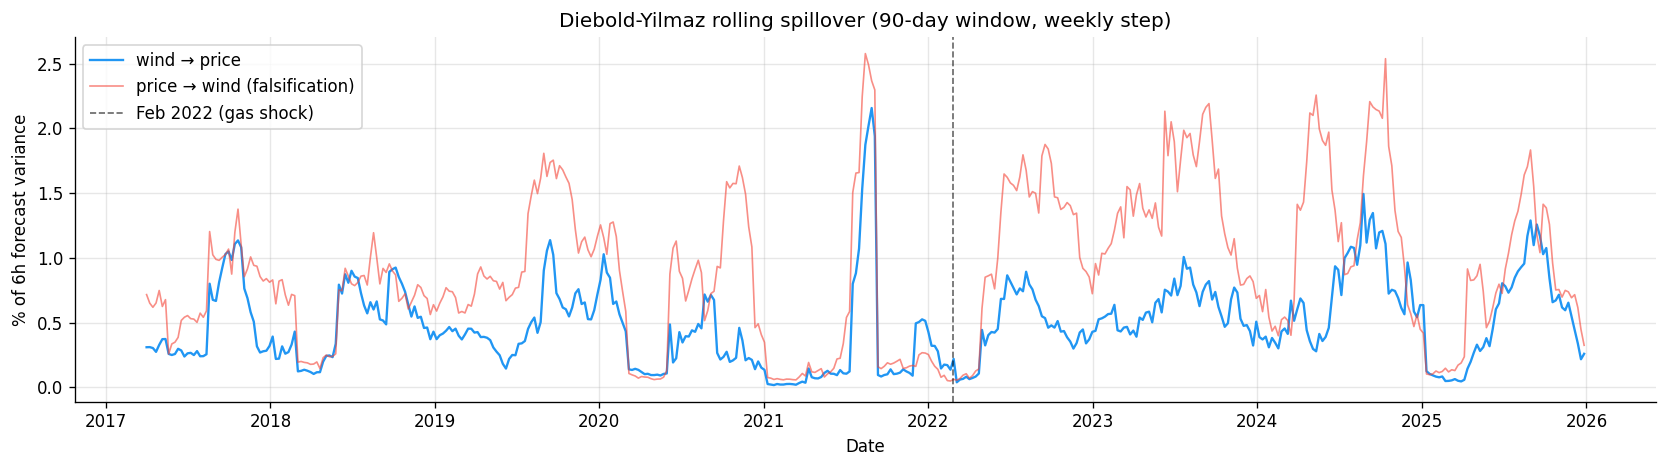


  → If wind→price share rises post-2022, corroborates the structural break result.


In [20]:
# CELL 12c — Cointegration, structural break, and rolling spillover
# ════════════════════════════════════════════════════════════════════════════════
# Three tests that tighten the econometric story:
#   (a) Johansen cointegration: is there a long-run wind-price equilibrium?
#   (b) Structural break (Chow-style): did the gas crisis change the slope?
#   (c) Diebold-Yilmaz rolling spillover: how does wind→price variance share
#       evolve across 2017–2026?

from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.stattools import adfuller

# ── (a) Johansen cointegration: wind level ↔ price level ─────────────────────
print("=" * 72)
print("(a) Johansen cointegration test: wind_level vs price_level")
print("=" * 72)
# Unit-root pre-check — cointegration only makes sense if both are I(1)
for name, s in [('mid_price', df_pd['mid_price']),
                (WIND_COL,    df_pd[WIND_COL])]:
    adf = adfuller(s.dropna(), maxlag=12, autolag=None)
    print(f"  ADF {name:20s}: stat={adf[0]:.2f}  p={adf[1]:.4f}  "
          f"{'→ I(1) candidate' if adf[1] > 0.05 else '→ stationary'}")

coint_df = df_pd[['mid_price', WIND_COL]].dropna()
try:
    joh = coint_johansen(coint_df, det_order=0, k_ar_diff=12)
    print("\n  Trace statistic vs 95% critical value:")
    for i, (stat, cv) in enumerate(zip(joh.lr1, joh.cvt[:, 1])):
        reject = " REJECT H0" if stat > cv else ""
        print(f"    r ≤ {i}: trace={stat:7.2f}  95%cv={cv:7.2f}{reject}")
    print("\n  Max-eigenvalue statistic vs 95% critical value:")
    for i, (stat, cv) in enumerate(zip(joh.lr2, joh.cvm[:, 1])):
        reject = " REJECT H0" if stat > cv else ""
        print(f"    r = {i}: maxeig={stat:7.2f}  95%cv={cv:7.2f}{reject}")
    n_coint = int(sum(joh.lr1 > joh.cvt[:, 1]))
    if n_coint == 0:
        print("\n  → No cointegration: wind and price have no long-run equilibrium.")
        print("    This is the expected result (price stationarises fast; wind trends).")
    else:
        print(f"\n  → {n_coint} cointegrating relation(s) found. Investigate further.")
except Exception as e:
    print(f"  Johansen failed: {e}")

# ── (b) Structural break: did the 2022 gas crisis change the wind→price slope? ──
print("\n" + "=" * 72)
print("(b) Structural break test: wind→price slope pre/post Feb 2022")
print("=" * 72)
break_date = pd.Timestamp('2022-02-24', tz='UTC')  # Russian invasion / gas shock
sb_df = pd.DataFrame({
    'ret':         df_pd['returns'],
    'wind_change': df_pd[WIND_COL].diff(),
    'start_time':  df_pd['start_time'],
}).dropna()
sb_df['post_2022'] = (sb_df['start_time'] >= break_date).astype(int)
sb_df['wind_x_post'] = sb_df['wind_change'] * sb_df['post_2022']

X_sb = sm.add_constant(sb_df[['wind_change', 'post_2022', 'wind_x_post']]).astype(np.float64)
y_sb = sb_df['ret'].astype(np.float64)
sb_fit = sm.OLS(y_sb, X_sb).fit(cov_type='HAC', cov_kwds={'maxlags': 48})
print(sb_fit.summary().tables[1])

pre_slope  = sb_fit.params['wind_change']
post_slope = sb_fit.params['wind_change'] + sb_fit.params['wind_x_post']
print(f"\n  Pre-Feb-2022  slope (wind_change → return): {pre_slope:+.6f}")
print(f"  Post-Feb-2022 slope (wind_change → return): {post_slope:+.6f}")
print(f"  Interaction t-stat: {sb_fit.tvalues['wind_x_post']:+.2f}  "
      f"(|t|>1.96 = break is significant)")
if abs(sb_fit.tvalues['wind_x_post']) > 1.96:
    direction = "STRONGER" if post_slope < pre_slope else "WEAKER"
    pct_change = 100 * (post_slope - pre_slope) / abs(pre_slope)
    print(f"  → Cannibalisation effect is {direction} post-2022 ({pct_change:+.0f}%)")

# ── (c) Diebold-Yilmaz rolling spillover index ───────────────────────────────
print("\n" + "=" * 72)
print("(c) Rolling Diebold-Yilmaz spillover: % of forecast variance wind→price")
print("=" * 72)
dy_df = pd.DataFrame({
    'returns':     df_pd['returns'].fillna(0).values,
    'wind_change': df_pd[WIND_COL].diff().fillna(0).values,
}, index=df_pd['start_time'])

WIN = 48 * 90   # 90-day rolling window
STEP = 48 * 7   # step 1 week
H    = 12       # forecast horizon for FEVD = 6h
LAG  = 6

dy_dates, dy_wind_to_price, dy_price_to_wind = [], [], []
print(f"  Rolling VAR(p={LAG}) over 90-day windows, step 1 week, h={H} FEVD...")
for start in range(0, len(dy_df) - WIN, STEP):
    window = dy_df.iloc[start:start + WIN]
    if window.std().min() < 1e-6:
        continue
    try:
        v = VAR(window).fit(LAG)
        decomp = v.fevd(H).decomp          # shape (n, h, n)
        # decomp[i, h-1, j] = share of i's forecast variance explained by j
        dy_wind_to_price.append(decomp[0, -1, 1])
        dy_price_to_wind.append(decomp[1, -1, 0])
        dy_dates.append(window.index[-1])
    except Exception:
        continue

dy_series = pd.DataFrame({
    'wind_to_price': dy_wind_to_price,
    'price_to_wind': dy_price_to_wind,
}, index=pd.DatetimeIndex(dy_dates))

print(f"\n  Mean wind→price share: {dy_series['wind_to_price'].mean()*100:.2f}%")
print(f"  Mean price→wind share: {dy_series['price_to_wind'].mean()*100:.2f}%")
print(f"  Wind→price range: [{dy_series['wind_to_price'].min()*100:.2f}%, "
      f"{dy_series['wind_to_price'].max()*100:.2f}%]")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dy_series.index, dy_series['wind_to_price']*100,
        lw=1.4, color='#2196F3', label='wind → price')
ax.plot(dy_series.index, dy_series['price_to_wind']*100,
        lw=1.0, color='#F44336', alpha=0.6, label='price → wind (falsification)')
ax.axvline(break_date, color='black', ls='--', lw=1, alpha=0.6,
           label='Feb 2022 (gas shock)')
ax.set_ylabel('% of 6h forecast variance')
ax.set_xlabel('Date')
ax.set_title('Diebold-Yilmaz rolling spillover (90-day window, weekly step)')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / '02_diebold_yilmaz.png', bbox_inches='tight')
plt.show()

print("\n  → If wind→price share rises post-2022, corroborates the structural break result.")

(a) Engle-Ng sign-bias test (asymmetry in volatility response)
  constant            : coef=+0.0016  t=+30.59  p=0.0000  ← SIGNIFICANT
  sign_bias           : coef=+0.9282  t= +8.52  p=0.0000  ← SIGNIFICANT
  negative_size_bias  : coef=+0.1415  t= +5.67  p=0.0000  ← SIGNIFICANT
  positive_size_bias  : coef=-0.0000  t= -9.41  p=0.0000  ← SIGNIFICANT

  Joint F-test (all 3 biases = 0): F=225.92  p=0.000000
  → Significant joint test justifies asymmetric GARCH (GJR/EGARCH) over plain GARCH.

(b) Zivot-Andrews unit root test (allowing one structural break)
  Subsampled to 26,293 obs (every 6th half-hour) for speed
  ZA failed: Unknown method

(c) Hurst exponent via rescaled-range analysis on |returns|
  Hurst(|returns|):   H = 0.603   long memory in vol
  Hurst(returns):     H = 0.634   persistent
  Hurst(returns²):    H = 0.599
  Stylised fact: electricity typically has H(|ret|) ≈ 0.7–0.9 — strong vol memory.

(d) Realized volatility signature: RV vs sampling frequency
 freq_min  n_obs  r

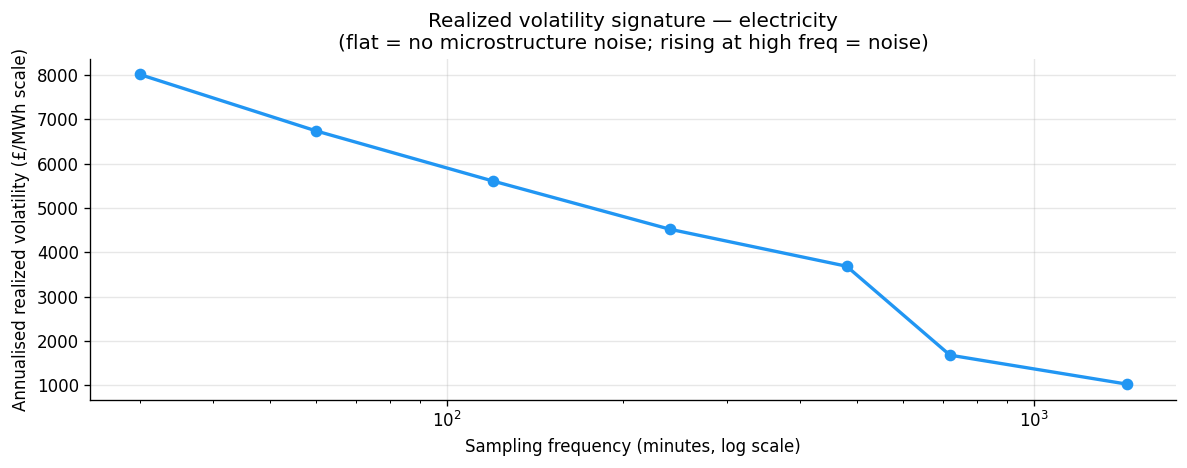


  Interpretation:
  - If RV is roughly flat across frequencies: no microstructure noise, the
    30-min settlement is clean enough that no subsampling correction needed.
  - If RV rises sharply below 1h: microstructure effects (may justify using
    hourly returns instead of 30-min for some downstream analyses).
  - If RV falls at high freq: price discreteness / settlement anchoring.


In [21]:
# CELL 12d — Sign-bias, Zivot-Andrews, Hurst, realized volatility signature
# ════════════════════════════════════════════════════════════════════════════════
# Four tests that formalise stylised facts the writeup should report:
#   (a) Engle-Ng sign-bias test  → justifies asymmetric GARCH over plain GARCH
#   (b) Zivot-Andrews unit root  → unit root test robust to one structural break
#   (c) Hurst exponent on |ret|  → long-memory in volatility (electricity fact)
#   (d) RV signature plot        → how volatility scales across sampling frequencies

from arch.unitroot import ZivotAndrews

# ── (a) Engle-Ng sign-bias test ──────────────────────────────────────────────
print("=" * 72)
print("(a) Engle-Ng sign-bias test (asymmetry in volatility response)")
print("=" * 72)
# Fit a baseline GARCH(1,1) and work with its standardised residuals²
base_garch = arch_model(arith_ret, vol='Garch', p=1, q=1, dist='t'
                        ).fit(disp='off', show_warning=False)
z       = (base_garch.resid / base_garch.conditional_volatility).dropna()
z_sq    = z**2
z_lag   = z.shift(1).dropna()
z_sq_al = z_sq.reindex(z_lag.index)
neg     = (z_lag < 0).astype(float)
pos     = (z_lag >= 0).astype(float)

X_sb = np.column_stack([
    np.ones(len(z_lag)),
    neg.values,               # sign bias: does sign of shock matter?
    (neg * z_lag).values,     # negative size bias: large negative shocks
    (pos * z_lag).values,     # positive size bias: large positive shocks
]).astype(np.float64)
y_sb = z_sq_al.values.astype(np.float64)

sb_res = sm.OLS(y_sb, X_sb).fit(cov_type='HAC', cov_kwds={'maxlags': 10})
labels = ['constant', 'sign_bias', 'negative_size_bias', 'positive_size_bias']
for lab, coef, t, p in zip(labels, sb_res.params, sb_res.tvalues, sb_res.pvalues):
    flag = "  ← SIGNIFICANT" if p < 0.05 else ""
    print(f"  {lab:20s}: coef={coef:+.4f}  t={t:+6.2f}  p={p:.4f}{flag}")
joint_f = sb_res.f_test(np.eye(4)[1:])     # joint test of 3 bias terms
print(f"\n  Joint F-test (all 3 biases = 0): F={float(joint_f.statistic):.2f}  "
      f"p={float(joint_f.pvalue):.6f}")
print("  → Significant joint test justifies asymmetric GARCH (GJR/EGARCH) over plain GARCH.")

# ── (b) Zivot-Andrews unit root with one structural break ────────────────────
print("\n" + "=" * 72)
print("(b) Zivot-Andrews unit root test (allowing one structural break)")
print("=" * 72)
# Subsample for tractability — full series is too slow
# ZA searches across possible break dates, O(n²) in length
za_sample = df_pd['mid_price'].dropna().iloc[::6]   # 6-th hour subsampling
print(f"  Subsampled to {len(za_sample):,} obs (every 6th half-hour) for speed")
try:
    za = ZivotAndrews(za_sample, trim=0.15, trend='c', method='AIC')
    print(f"  Test statistic: {za.stat:.3f}")
    print(f"  5% critical:    {za.critical_values['5%']:.3f}")
    print(f"  p-value:        {za.pvalue:.4f}")
    if za.pvalue < 0.05:
        print("  → Reject unit root even allowing for one structural break.")
        print("    Price is stationary around a level shift (consistent with 2022 gas shock).")
    else:
        print("  → Cannot reject unit root. Prices may genuinely be I(1).")
except Exception as e:
    print(f"  ZA failed: {e}")

# ── (c) Hurst exponent on |returns| — long memory in volatility ──────────────
print("\n" + "=" * 72)
print("(c) Hurst exponent via rescaled-range analysis on |returns|")
print("=" * 72)
def hurst_rs(series, min_chunk=16, max_chunk=None):
    """Classic R/S Hurst estimator. Returns H ∈ (0,1).
    H=0.5 random walk, H>0.5 persistent (long memory), H<0.5 anti-persistent."""
    s = np.asarray(series, dtype=float)
    s = s[np.isfinite(s)]
    n = len(s)
    if max_chunk is None:
        max_chunk = n // 4
    chunks = np.unique(np.logspace(np.log10(min_chunk),
                                    np.log10(max_chunk), 20).astype(int))
    rs = []
    for c in chunks:
        n_blocks = n // c
        if n_blocks < 1:
            continue
        blocks = s[:n_blocks * c].reshape(n_blocks, c)
        mean_adj = blocks - blocks.mean(axis=1, keepdims=True)
        z        = mean_adj.cumsum(axis=1)
        r        = z.max(axis=1) - z.min(axis=1)
        std      = blocks.std(axis=1, ddof=1)
        valid    = std > 1e-12
        if valid.sum() == 0:
            continue
        rs.append(np.mean(r[valid] / std[valid]))
    chunks = chunks[:len(rs)]
    log_c  = np.log(chunks)
    log_rs = np.log(rs)
    H, _   = np.polyfit(log_c, log_rs, 1)
    return H

H_abs = hurst_rs(arith_ret.abs().values)
H_ret = hurst_rs(arith_ret.values)
H_sq  = hurst_rs((arith_ret**2).values)
print(f"  Hurst(|returns|):   H = {H_abs:.3f}   "
      f"{'long memory in vol' if H_abs > 0.55 else 'short memory'}")
print(f"  Hurst(returns):     H = {H_ret:.3f}   "
      f"{'mean-reverting' if H_ret < 0.45 else 'near-random-walk' if H_ret < 0.55 else 'persistent'}")
print(f"  Hurst(returns²):    H = {H_sq:.3f}")
print("  Stylised fact: electricity typically has H(|ret|) ≈ 0.7–0.9 — strong vol memory.")

# ── (d) Realized volatility signature plot ───────────────────────────────────
print("\n" + "=" * 72)
print("(d) Realized volatility signature: RV vs sampling frequency")
print("=" * 72)
price_idx = df_pd.set_index('start_time')['mid_price'].dropna()
freqs_min = [30, 60, 120, 240, 480, 720, 1440]  # 30m to 1d
sig_rows  = []
for f in freqs_min:
    rule = f'{f}min'
    p_rs = price_idx.resample(rule).last().dropna()
    r_rs = p_rs.diff().dropna()
    # Annualised RV (sqrt of mean of squared returns × periods-per-year)
    periods_per_year = 365 * 24 * 60 / f
    rv_annual = np.sqrt(np.mean(r_rs**2) * periods_per_year)
    sig_rows.append(dict(freq_min=f, n_obs=len(r_rs), rv_annual=rv_annual))
sig_df = pd.DataFrame(sig_rows)
print(sig_df.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sig_df['freq_min'], sig_df['rv_annual'], 'o-', lw=2, color='#2196F3')
ax.set_xscale('log')
ax.set_xlabel('Sampling frequency (minutes, log scale)')
ax.set_ylabel('Annualised realized volatility (£/MWh scale)')
ax.set_title('Realized volatility signature — electricity\n'
             '(flat = no microstructure noise; rising at high freq = noise)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(DATA_DIR / '02_rv_signature.png', bbox_inches='tight')
plt.show()

print("\n  Interpretation:")
print("  - If RV is roughly flat across frequencies: no microstructure noise, the")
print("    30-min settlement is clean enough that no subsampling correction needed.")
print("  - If RV rises sharply below 1h: microstructure effects (may justify using")
print("    hourly returns instead of 30-min for some downstream analyses).")
print("  - If RV falls at high freq: price discreteness / settlement anchoring.")

(a) HAR-RV — forecasting realized volatility
  Daily RV series: 3,287 days
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.271e+08   7.14e+07      4.584      0.000    1.87e+08    4.67e+08
rv_d           0.0389      0.034      1.152      0.249      -0.027       0.105
rv_w           0.1185      0.099      1.200      0.230      -0.075       0.312
rv_m           0.5516      0.119      4.631      0.000       0.318       0.785

  HAR R² = 0.0850
  Interpretation: β_d (daily) + β_w (weekly) + β_m (monthly) give the
  relative weight of each horizon in volatility forecasting.
  This is the Corsi-standard baseline for RV forecasting — any fancier
  volatility model (LSTM, GARCH-forecast) should beat this R².

(b) PCA on stage1 survivors — effective dim of conditioning space
  Features included: 21
  Samples:           157,776

  Cumulative variance explained by first k com

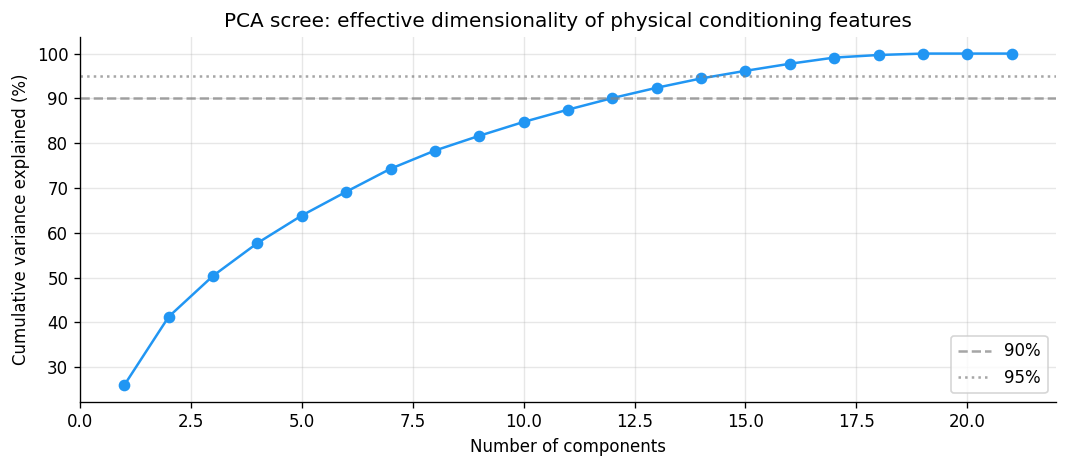


  Top features by absolute loading on PC1-PC3:
    PC1: renewable_fraction(+0.36), north_scotland_carbon_intensity(-0.36), south_scotland_carbon_intensity(-0.35), wind(+0.34), total_wind_mw(+0.34)
    PC2: intifa2(+0.34), wind(-0.30), total_wind_mw(-0.30), intelec(+0.29), intew(-0.29)
    PC3: npshyd(+0.58), ps(+0.57), ocgt(+0.38), other(+0.27), total_wind_mw(+0.19)

(c) Kolmogorov-Smirnov: do price-regimes have distinct return distributions?
  Pairwise KS statistics (p-values in parens, * if p<0.01):
                         calm       volatile          spike       negative
  calm                        0.425(0.0e+00)* 0.272(0.0e+00)* 0.261(1.4e-94)* 
  volatile                                   0.450(0.0e+00)* 0.370(1.3e-159)* 
  spike                                                     0.363(5.9e-155)* 
  negative                                                                 

  Large KS stats + tiny p-values = regimes genuinely have different return
  distributions (not just dif

In [22]:
# CELL 12e — HAR-RV, PCA of physical features, KS regime separation
# ════════════════════════════════════════════════════════════════════════════════
# Three diagnostics useful for conditioning-signal design and latent sizing:
#   (a) HAR-RV (Corsi 2009)   → baseline RV forecast; used as conditioning target
#   (b) PCA of stage1 vars    → effective dim of physical conditioning space
#   (c) KS two-sample tests   → do the regimes have distinct return distributions?

from sklearn.decomposition import PCA
from scipy.stats import ks_2samp

# ── (a) HAR-RV: Corsi (2009) heterogeneous autoregressive model of RV ────────
print("=" * 72)
print("(a) HAR-RV — forecasting realized volatility")
print("=" * 72)
# Build daily RV from 30-min returns
daily_rv = (arith_ret.groupby(df_pd['start_time'].dt.date)
            .apply(lambda x: np.sqrt(np.sum(x**2))))
daily_rv.index = pd.to_datetime(daily_rv.index)
print(f"  Daily RV series: {len(daily_rv):,} days")

# HAR: RV_t = α + β_d·RV_{t-1} + β_w·mean(RV_{t-5:t-1}) + β_m·mean(RV_{t-22:t-1}) + ε
har_df = pd.DataFrame({
    'rv':     daily_rv,
    'rv_d':   daily_rv.shift(1),
    'rv_w':   daily_rv.shift(1).rolling(5).mean(),
    'rv_m':   daily_rv.shift(1).rolling(22).mean(),
}).dropna()
X_har = sm.add_constant(har_df[['rv_d','rv_w','rv_m']]).astype(np.float64)
y_har = har_df['rv'].astype(np.float64)
har_fit = sm.OLS(y_har, X_har).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
print(har_fit.summary().tables[1])
print(f"\n  HAR R² = {har_fit.rsquared:.4f}")
print("  Interpretation: β_d (daily) + β_w (weekly) + β_m (monthly) give the")
print("  relative weight of each horizon in volatility forecasting.")
print("  This is the Corsi-standard baseline for RV forecasting — any fancier")
print("  volatility model (LSTM, GARCH-forecast) should beat this R².")

# Save HAR fitted values as candidate conditioning signal for SigCWGAN/neural SDE
har_df['rv_har_pred'] = har_fit.fittedvalues
df_pd['har_rv_pred_daily'] = df_pd['start_time'].dt.normalize().map(
    har_df['rv_har_pred'].to_dict())

# ── (b) PCA on surviving physical features — effective dimensionality ───────
print("\n" + "=" * 72)
print("(b) PCA on stage1 survivors — effective dim of conditioning space")
print("=" * 72)
pca_cols = [c for c in stage1_pass if c in df_pd.columns
            and pd.api.types.is_numeric_dtype(df_pd[c])]
X_pca = df_pd[pca_cols].ffill().bfill().dropna()
X_pca_sc = StandardScaler().fit_transform(X_pca)
pca = PCA().fit(X_pca_sc)
cumvar = np.cumsum(pca.explained_variance_ratio_)

print(f"  Features included: {len(pca_cols)}")
print(f"  Samples:           {len(X_pca_sc):,}")
print("\n  Cumulative variance explained by first k components:")
for k in [1, 2, 3, 5, 8, 10, len(pca_cols)]:
    if k <= len(cumvar):
        print(f"    k={k:2d}: {cumvar[k-1]*100:5.2f}%")

# Effective dimensionality: how many components to reach 90%?
n_90 = int(np.searchsorted(cumvar, 0.90) + 1)
n_95 = int(np.searchsorted(cumvar, 0.95) + 1)
print(f"\n  Components to reach 90% variance: {n_90}")
print(f"  Components to reach 95% variance: {n_95}")
print(f"  → Suggests LATENT_DIM ≥ {n_90} is needed to preserve physical info content.")
print(f"    (Current CVAE LATENT_DIM=16 — should be ≥ {n_90} for no info loss.)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cumvar)+1), cumvar*100, 'o-', color='#2196F3')
ax.axhline(90, color='grey', ls='--', alpha=0.7, label='90%')
ax.axhline(95, color='grey', ls=':',  alpha=0.7, label='95%')
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative variance explained (%)')
ax.set_title('PCA scree: effective dimensionality of physical conditioning features')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(DATA_DIR / '02_pca_scree.png', bbox_inches='tight')
plt.show()

# Top-5 features loading each of PC1-PC3
print("\n  Top features by absolute loading on PC1-PC3:")
loadings = pd.DataFrame(pca.components_[:3].T,
                        index=pca_cols,
                        columns=['PC1','PC2','PC3'])
for pc in ['PC1','PC2','PC3']:
    top = loadings[pc].abs().nlargest(5)
    print(f"    {pc}: {', '.join(f'{c}({loadings.loc[c, pc]:+.2f})' for c in top.index)}")

# ── (c) KS two-sample tests across regimes ──────────────────────────────────
print("\n" + "=" * 72)
print("(c) Kolmogorov-Smirnov: do price-regimes have distinct return distributions?")
print("=" * 72)
regimes = ['calm', 'volatile', 'spike', 'negative']
returns_by_regime = {r: df_pd.loc[df_pd['regime'] == r, 'returns'].dropna().values
                     for r in regimes}
print("  Pairwise KS statistics (p-values in parens, * if p<0.01):")
print(f"  {'':12s} " + ' '.join(f"{r:>14s}" for r in regimes))
for i, r1 in enumerate(regimes):
    row = f"  {r1:12s} "
    for j, r2 in enumerate(regimes):
        if j <= i:
            row += f"{'':>14s} "
        else:
            a, b = returns_by_regime[r1], returns_by_regime[r2]
            if len(a) < 20 or len(b) < 20:
                row += f"{'n/a':>14s} "
                continue
            ks_stat, ks_p = ks_2samp(a, b)
            marker = '*' if ks_p < 0.01 else ' '
            row += f"{ks_stat:.3f}({ks_p:.1e}){marker} "
    print(row)
print("\n  Large KS stats + tiny p-values = regimes genuinely have different return")
print("  distributions (not just different means). Justifies regime-conditioned")
print("  generative modelling.")

## 5. Volatility & Econometric Modeling
This section delves into the market's response to the physical variables. We run:
- GARCH/EGARCH grid searches for the best price volatility model.
- VAR models and Granger causality to prove wind drives price (and not vice versa).
- Johansen cointegration and structural break tests (e.g., the 2022 gas shock).

Price stats by wind penetration quintile:
        mean     std  count
pen_q                      
0.0    95.38  150.17  31438
1.0    88.76   88.06  31439
2.0    84.44   72.75  31438
3.0    78.86   63.56  31435
4.0    62.84   68.83  31441

B6 threshold evidence (non-monotone price std): True


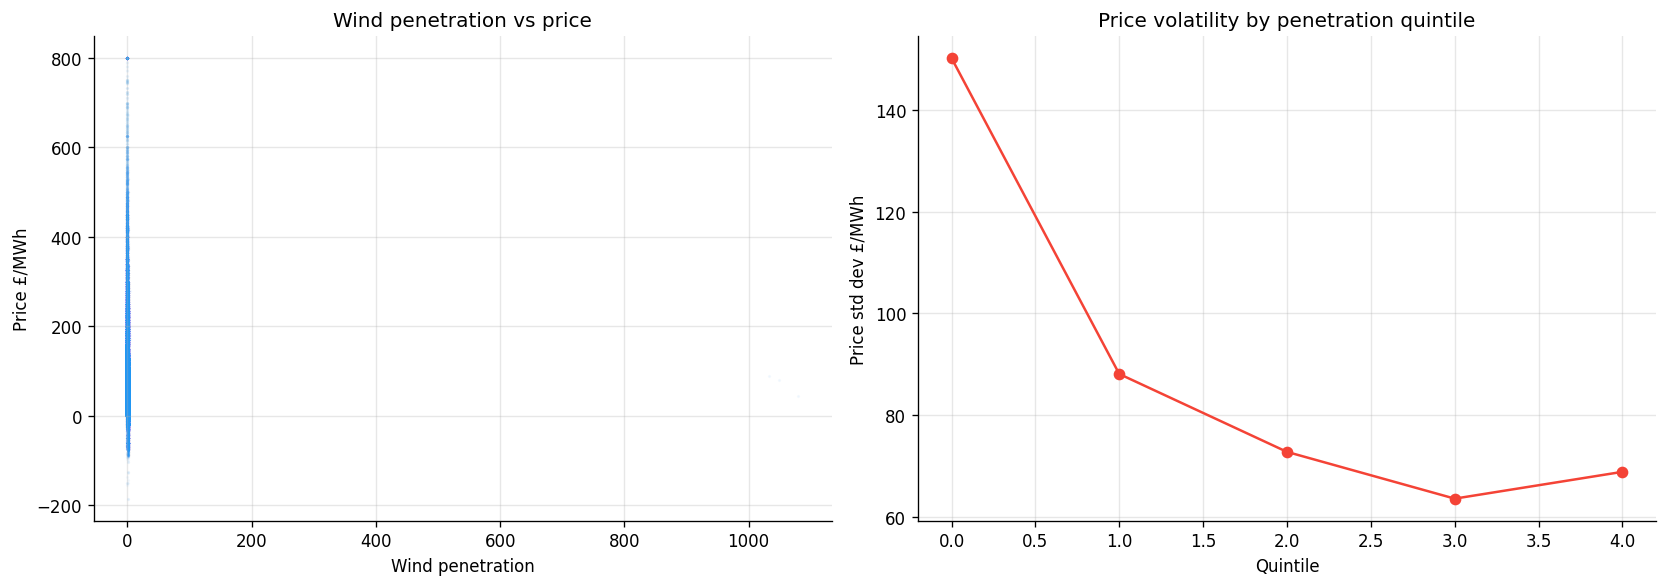

In [23]:
# CELL 13 — B6/hydro threshold test
# ════════════════════════════════════════════════════════════════════════════════

b6_evidence = False
if 'total_generation_mw' in df_pd.columns:
    df_pd['wind_pen'] = df_pd[WIND_COL] / (df_pd['total_generation_mw'].clip(lower=1) + 1e-6)
    df_pd['pen_q']    = pd.qcut(df_pd['wind_pen'].clip(0,1), 5, labels=False, duplicates='drop')

    qst  = df_pd.groupby('pen_q')['mid_price'].agg(['mean','std','count'])
    stds = df_pd.groupby('pen_q')['mid_price'].std()
    d    = stds.diff().dropna()
    b6_evidence = not all(x>=0 for x in d) and not all(x<=0 for x in d)

    print("Price stats by wind penetration quintile:")
    print(qst.round(2))
    print(f"\nB6 threshold evidence (non-monotone price std): {b6_evidence}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(df_pd['wind_pen'], df_pd['mid_price'].clip(-200,800),
                    alpha=0.04, s=1, c='#2196F3')
    axes[0].set_xlabel('Wind penetration'); axes[0].set_ylabel('Price £/MWh')
    axes[0].set_title('Wind penetration vs price')
    axes[1].plot(stds.index, stds.values, 'o-', color='#F44336')
    axes[1].set_xlabel('Quintile'); axes[1].set_ylabel('Price std dev £/MWh')
    axes[1].set_title('Price volatility by penetration quintile')
    plt.tight_layout()
    plt.savefig(DATA_DIR / '02_b6_threshold.png', bbox_inches='tight')
    plt.show()
else:
    print("total_generation_mw not in master.parquet — skipping B6 test")


In [24]:
# CELL 14 — Seasonality test: do settlement-period dummies improve ARIMAX?
# ════════════════════════════════════════════════════════════════════════════════
# AIC improvement > 10 → learnable embeddings (nn.Embedding(48,4)) justified.

df_pd['sp'] = (df_pd['start_time'].dt.hour * 2 +
               df_pd['start_time'].dt.minute // 30 + 1).astype(int)
sp_dum = pd.get_dummies(df_pd['sp'], prefix='sp', drop_first=True).astype(int)

idx      = endog.index.intersection(exog.index).intersection(sp_dum.index)
exog_s   = pd.concat([exog.loc[idx], sp_dum.loc[idx]], axis=1)

print("Fitting ARIMAX(4,0,4) + 47 settlement-period dummies...")
arima_seasonal   = SARIMAX(endog.loc[idx], exog=exog_s, order=(4,0,4),
                            enforce_stationarity=False,
                            enforce_invertibility=False).fit(disp=False)
aic_improvement  = arima_fit.aic - arima_seasonal.aic
embedding_recommended = aic_improvement > 10

print(f"AIC without season: {arima_fit.aic:.1f}")
print(f"AIC with season:    {arima_seasonal.aic:.1f}")
print(f"AIC improvement:    {aic_improvement:.1f}")
print(f"Embedding recommended: {embedding_recommended}  (threshold = 10)")

Fitting ARIMAX(4,0,4) + 47 settlement-period dummies...
AIC without season: 1707591.6
AIC with season:    1705894.6
AIC improvement:    1697.0
Embedding recommended: True  (threshold = 10)


In [25]:
# CELL 15 — STEP_SIZE decision
# ════════════════════════════════════════════════════════════════════════════════

below2        = np.where(np.abs(acf_ret[1:]) < conf_band)[0]
acf_timescale = int(below2[0]) + 1 if len(below2) > 0 else 96

SEGMENT_LENGTH        = 72   # 36 hours; see Cell 16 rationale
STEP_SIZE_RECOMMENDED = 12 if acf_timescale > 12 else 24
STEP_SIZE             = STEP_SIZE_RECOMMENDED

print(f"ACF timescale: {acf_timescale} half-hours = {acf_timescale/2:.1f} hours")
print(f"STEP_SIZE=24 → ~{(len(df_pd)-72)//24:,} segments")
print(f"STEP_SIZE=12 → ~{(len(df_pd)-72)//12:,} segments")
print(f"Recommended STEP_SIZE: {STEP_SIZE}")




ACF timescale: 7 half-hours = 3.5 hours
STEP_SIZE=24 → ~6,571 segments
STEP_SIZE=12 → ~13,142 segments
Recommended STEP_SIZE: 24


## 6. Segment Generation (36-Hour Windows)
We chunk our continuous time-series into 36-hour segments (`SEGMENT_LENGTH=72`). This specific window size captures the crucial overnight-into-morning wind/price dynamics (diurnal ramps). We compute moving averages, rolling variances, and previous-segment tags for our conditioning vectors.

In [26]:
# CELL 16 — Segment generation (SEGMENT_LENGTH=72, STEP_SIZE from Cell 15)
# ════════════════════════════════════════════════════════════════════════════════
# SEGMENT_LENGTH=72 rationale (vs 48):
#   Spans overnight→morning transition, capturing diurnal wind ramp preceding
#   morning price spikes. By Lyons (1998) rough paths theory, the level-2 Lévy
#   area contains information NOT determined by the path increments alone.
#   Chen's identity: sig([a,c]) contains cross-terms between [a,b] and [b,c]
#   sub-intervals — the overnight-into-morning wind-price coupling sits here.
#   Factorial decay bound |S^k| ≤ ‖X‖^k/k! ensures level-2/3 terms remain
#   numerically meaningful at 72 steps. Cost: negligible vs 48-period segments.


prices  = df_pd['mid_price'].to_numpy()
n_total = len(prices)

def seg_regime(s, e):
    w = df_pd['regime'].iloc[s:e].tolist()
    for r in ('spike','negative','volatile','calm'):
        if r in w: return r
    return 'calm'

def seg_alt_state(s, e):
    w = df_pd['alt_state'].iloc[s:e].dropna()
    return float(w.mode().iloc[0]) if len(w) > 0 else np.nan

print(f"Generating segments: SEGMENT_LENGTH={SEGMENT_LENGTH}, STEP_SIZE={STEP_SIZE}...")
segs = []
for start in range(0, n_total - SEGMENT_LENGTH, STEP_SIZE):
    end = start + SEGMENT_LENGTH
    seg = {
        'start_idx':      start,
        'end_idx':        end,
        'start_time':     df_pd['start_time'].iloc[start],
        'regime':         seg_regime(start, end),
        'alt_state':      seg_alt_state(start, end),
        # Unlagged aggregates (for Stage 2 CV test)
        'wind_mean':       df_pd[WIND_COL].iloc[start:end].mean(),
        'wind_var_mean':   df_pd['sigma2_wind'].iloc[start:end].mean(),
        'nuclear_mean':    df_pd['nuclear'].iloc[start:end].mean() if 'nuclear' in df_pd else np.nan,
        'ps_mean':         df_pd[PS_COL].iloc[start:end].mean() if PS_COL in df_pd.columns else np.nan,
        'ci_north_mean':   df_pd['north_scotland_carbon_intensity'].iloc[start:end].mean()
                           if 'north_scotland_carbon_intensity' in df_pd else np.nan,
        'npshyd_mean':     df_pd['npshyd'].iloc[start:end].mean() if 'npshyd' in df_pd else np.nan,
        'RV':              float(np.std(np.diff(prices[start:end]))),
        'garch_var_mean':  df_pd['sigma2_price'].iloc[start:end].mean(),
        'har_rv_prev': df_pd['har_rv_pred_daily'].iloc[start:end].mean(),
    }
    # Additional stage1 survivors
    for col in stage1_pass:
        if col not in seg and col in df_pd.columns:
            seg[f'{col}_mean'] = df_pd[col].iloc[start:end].mean()
    segs.append(seg)

df_seg = pd.DataFrame(segs)

# Lagged conditioning vars (ALWAYS .shift(1) — no look-ahead)
df_seg['wind_prev_mean']     = df_seg['wind_mean'].shift(1)
df_seg['wind_var_prev_mean'] = df_seg['wind_var_mean'].shift(1)
df_seg['nuclear_prev_mean']  = df_seg['nuclear_mean'].shift(1)
df_seg['ps_prev_sign']       = np.sign(df_seg['ps_mean'].shift(1))  # -1 / 0 / +1
df_seg['ci_north_prev_mean'] = df_seg['ci_north_mean'].shift(1)
df_seg['npshyd_prev_mean']   = df_seg['npshyd_mean'].shift(1)
df_seg['RV_prev']            = df_seg['RV'].shift(1)
df_seg['garch_var_prev']     = df_seg['garch_var_mean'].shift(1)
df_seg['alt_state_prev']     = df_seg['alt_state'].shift(1)
df_seg['regime_prev']        = df_seg['regime'].shift(1)
df_seg['har_rv_prev_mean'] = df_seg['har_rv_prev'].shift(1)

for col in stage1_pass:
    raw = f'{col}_mean'
    if raw in df_seg.columns:
        df_seg[f'{col}_prev_mean'] = df_seg[raw].shift(1)

df_seg['price_transition'] = (df_seg['regime_prev'].fillna('?') + '→' + df_seg['regime'])
df_seg['alt_transition']   = (df_seg['alt_state_prev'].astype(str).str.replace('nan','?') +
                               '→' + df_seg['alt_state'].astype(str))

df_seg = df_seg.dropna(subset=['RV_prev']).reset_index(drop=True)

print(f"\nSegments: {len(df_seg):,}")
print("\nPrice-regime distribution:")
print(df_seg['regime'].value_counts())
print("\nGMM alt-state distribution:")
print(df_seg['alt_state'].value_counts().sort_index())
print("\nTop price transition types:")
print(df_seg['price_transition'].value_counts().head(8))


Generating segments: SEGMENT_LENGTH=72, STEP_SIZE=24...

Segments: 6,530

Price-regime distribution:
regime
calm        1963
spike       1940
volatile    1827
negative     800
Name: count, dtype: int64

GMM alt-state distribution:
alt_state
0.0    3132
1.0    1887
2.0     989
3.0     522
Name: count, dtype: int64

Top price transition types:
price_transition
spike→spike          1757
calm→calm            1657
volatile→volatile    1414
negative→negative     626
volatile→calm         207
calm→volatile         206
volatile→spike        121
spike→volatile        116
Name: count, dtype: int64


In [27]:
# CELL 16b — Apply refined regime labels to df_seg
# ════════════════════════════════════════════════════════════════════════════════
# Run this IMMEDIATELY after Cell 16 (segment generation).
# Depends on: df_seg (Cell 16), refined_regime() (Cell 8d),
#             df_pd spike_subtype/calm_subtype (Cell 8d).

print("Applying refined regime labels to df_seg...")
df_seg['regime_refined'] = [
    refined_regime(int(row['start_idx']), int(row['end_idx']))
    for _, row in df_seg.iterrows()
]

df_seg['refined_transition'] = (
    df_seg['regime_refined'].shift(1).fillna('?') +
    '→' + df_seg['regime_refined']
)

print("\nRefined regime distribution in segments:")
print(df_seg['regime_refined'].value_counts())

print("\nRefined transition distribution (top 15):")
print(df_seg['refined_transition'].value_counts().head(15))

n_spike_sub = df_seg['regime_refined'].str.startswith('spike').sum()
n_calm_sub  = df_seg['regime_refined'].str.startswith('calm').sum()
print(f"\nSpike sub-typed: {n_spike_sub} segments")
print(f"Calm sub-typed:  {n_calm_sub} segments")
print(f"Other:           {len(df_seg) - n_spike_sub - n_calm_sub} segments")

Applying refined regime labels to df_seg...

Refined regime distribution in segments:
regime_refined
volatile                    1827
negative                     913
spike_moderate_sustained     761
calm_mid_wind_calm           733
spike_extreme_sustained      712
calm_high_wind_calm          657
calm_low_wind_calm           573
spike_moderate_brief         187
spike_extreme_brief          167
Name: count, dtype: int64

Refined transition distribution (top 15):
refined_transition
volatile→volatile                                    1414
negative→negative                                     721
spike_moderate_sustained→spike_moderate_sustained     631
spike_extreme_sustained→spike_extreme_sustained       559
calm_mid_wind_calm→calm_mid_wind_calm                 469
calm_high_wind_calm→calm_high_wind_calm               462
calm_low_wind_calm→calm_low_wind_calm                 391
spike_extreme_brief→spike_extreme_brief               103
spike_moderate_brief→spike_moderate_brief         

In [28]:
# CELL 16c — PS segment-level analysis (run after Cell 16)
# ════════════════════════════════════════════════════════════════════════════════
# Depends on: df_seg (Cell 16), df_pd['ps'] (Cell 8e)

if 'ps' in df_pd.columns:
    ps      = df_pd['ps'].fillna(0)
    ps_sign = np.sign(ps)

    # Sign-change frequency and mean PS per segment
    sign_changes_per_seg = []
    ps_mean_per_seg      = []
    for _, row in df_seg.iterrows():
        s, e      = int(row['start_idx']), int(row['end_idx'])
        ps_seg    = ps_sign.iloc[s:e].dropna().to_numpy()
        n_changes = (np.diff(ps_seg) != 0).sum() if len(ps_seg) > 1 else 0
        sign_changes_per_seg.append(n_changes)
        ps_mean_per_seg.append(ps.iloc[s:e].mean())

    df_seg['ps_sign_changes'] = sign_changes_per_seg
    df_seg['ps_seg_mean']     = ps_mean_per_seg

    print("PS sign changes per 36h segment:")
    print(df_seg['ps_sign_changes'].describe().round(1))
    print(f"\n% segments with ≥3 sign changes: {(df_seg['ps_sign_changes']>=3).mean()*100:.1f}%")
    print(f"% segments with 0 sign changes:  {(df_seg['ps_sign_changes']==0).mean()*100:.1f}%")
    print(f"\nps_prev_sign value counts (should be all +1 if always turbining):")
    print(df_seg['ps_prev_sign'].value_counts())

    # Price distribution by lagged PS sign
    seg_prices = [df_pd['mid_price'].iloc[int(r['start_idx']):int(r['end_idx'])].mean()
                  for _, r in df_seg.iterrows()]
    df_seg['seg_mean_price'] = seg_prices

    df_seg['ps_prev_sign_cat'] = df_seg['ps_prev_sign'].map(
        {-1.0: 'pumping', 0.0: 'balanced', 1.0: 'turbining'})
    print("\nNext-segment mean price by lagged PS sign:")
    for cat in ['pumping', 'balanced', 'turbining']:
        mask = df_seg['ps_prev_sign_cat'] == cat
        if mask.sum() < 5: continue
        p = df_seg.loc[mask, 'seg_mean_price']
        print(f"  prev_ps={cat:10s}: n={mask.sum():4}  "
              f"mean=£{p.mean():.1f}  std=£{p.std():.1f}")

    # AUROC: PS sign vs wind level vs nuclear for predicting next-segment spike
    df_seg['next_is_spike'] = (df_seg['regime'].shift(-1) == 'spike').astype(int)
    print("\nAUROC for predicting next-segment spike:")
    for pred_col, label in [
        ('ps_prev_sign',      'PS prev sign'),
        ('wind_prev_mean',    'Wind prev mean'),
        ('nuclear_prev_mean', 'Nuclear prev mean'),
        ('RV_prev',           'RV prev'),
    ]:
        if pred_col not in df_seg.columns: continue
        Xp = df_seg[[pred_col]].dropna()
        yp = df_seg['next_is_spike'].reindex(Xp.index).dropna()
        Xp = Xp.reindex(yp.index)
        if len(yp) < 20 or yp.sum() < 5: continue
        try:
            Xsc   = StandardScaler().fit_transform(Xp)
            lr    = LogisticRegression(random_state=42, max_iter=300)
            lr.fit(Xsc, yp)
            auroc = roc_auc_score(yp, lr.predict_proba(Xsc)[:,1])
            print(f"  {label:25s}: AUROC = {auroc:.3f}")
        except Exception as ex:
            print(f"  {label}: {ex}")
else:
    print("ps not in df_pd — skipping Cell 16c")




PS sign changes per 36h segment:
count    6530.0
mean        9.2
std         5.1
min         0.0
25%         5.0
50%         9.0
75%        13.0
max        31.0
Name: ps_sign_changes, dtype: float64

% segments with ≥3 sign changes: 99.4%
% segments with 0 sign changes:  0.0%

ps_prev_sign value counts (should be all +1 if always turbining):
ps_prev_sign
1.0    6529
Name: count, dtype: int64

Next-segment mean price by lagged PS sign:
  prev_ps=turbining : n=6529  mean=£82.0  std=£66.0

AUROC for predicting next-segment spike:
  PS prev sign             : AUROC = 0.500
  Wind prev mean           : AUROC = 0.684
  Nuclear prev mean        : AUROC = 0.746
  RV prev                  : AUROC = 0.488


In [29]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 16d — CCGT/OCGT segment-level lagged vars (run after Cell 16)
# ════════════════════════════════════════════════════════════════════════════════
# Depends on: df_seg (Cell 16), df_pd ccgt_fraction/ocgt_active (Cell 8f)

if 'ccgt_fraction' in df_pd.columns:
    for col in ['ccgt_fraction', 'ocgt_active']:
        if col not in df_pd.columns: continue

        # Mean over each segment window
        raw_col = f'{col}_mean'
        df_seg[raw_col] = [
            df_pd[col].iloc[int(r['start_idx']):int(r['end_idx'])].mean()
            for _, r in df_seg.iterrows()
        ]
        # Lagged (previous segment) — the actual conditioning var
        df_seg[f'{col}_prev_mean'] = df_seg[raw_col].shift(1)

        # Within-segment CV
        ws, wm = [], []
        for _, row in df_seg.iterrows():
            s, e = int(row['start_idx']), int(row['end_idx'])
            vals = df_pd[col].iloc[s:e].dropna()
            if len(vals) > 1:
                ws.append(vals.std()); wm.append(abs(vals.mean()))
        cv = np.mean(ws) / (np.mean(wm) + 1e-6) if ws else np.nan
        print(f"CV({col}): {cv:.3f}  — "
              f"{'HIGH: mean is rough summary' if cv > 0.5 else 'acceptable aggregation'}")

    print("\nNew lagged vars added to df_seg:")
    new_cols = [c for c in df_seg.columns if 'ccgt' in c or 'ocgt' in c]
    print(f"  {new_cols}")
    print("\nSample (first 5 rows):")
    print(df_seg[new_cols].head().round(3).to_string())
else:
    print("ccgt_fraction not in df_pd — run Cell 8f first")

CV(ccgt_fraction): 0.264  — acceptable aggregation
CV(ocgt_active): 2.015  — HIGH: mean is rough summary

New lagged vars added to df_seg:
  ['ocgt_mean', 'ocgt_prev_mean', 'ccgt_fraction_mean', 'ccgt_fraction_prev_mean', 'ocgt_active_mean', 'ocgt_active_prev_mean']

Sample (first 5 rows):
   ocgt_mean  ocgt_prev_mean  ccgt_fraction_mean  ccgt_fraction_prev_mean  ocgt_active_mean  ocgt_active_prev_mean
0      0.000             0.0               0.300                      NaN             0.000                    NaN
1      0.000             0.0               0.304                    0.300             0.000                    0.0
2      0.000             0.0               0.310                    0.304             0.000                    0.0
3      0.000             0.0               0.279                    0.310             0.000                    0.0
4      6.028             0.0               0.330                    0.279             0.056                    0.0


## 7. Stage 2 Screening & Markov Chain Dynamics
With segments generated, we perform a second pass of feature screening (testing within-segment coefficient of variation and redundancy). We also model the sequence of GMM states as a Markov Chain to understand mixing times, expected sojourn times, and long-run stationary distributions (vital for hedging simulations).

In [30]:
# CELL 17 — Stage 2 screening: criterion 1 (CV) + criterion 3 (redundancy)
# ════════════════════════════════════════════════════════════════════════════════

print("Criterion 1 — within-segment variation (CV = mean_std / mean|mean|):")
print("CV > 0.5: changes substantially within 36h (aggregation choice matters)")
print("CV < 0.1: approximately constant (mean aggregation valid)\n")

cv_results = {}
for col in stage1_pass:
    if col not in df_pd.columns: continue
    ws, wm = [], []
    for _, row in df_seg.iterrows():
        s, e   = int(row['start_idx']), int(row['end_idx'])
        vals   = df_pd[col].iloc[s:e].dropna()
        if len(vals) > 1:
            ws.append(vals.std()); wm.append(abs(vals.mean()))
    if ws:
        cv = np.mean(ws) / (np.mean(wm) + 1e-6)
        cv_results[col] = cv
        flag = "  ← HIGH" if cv > 0.5 else ("  ← low" if cv < 0.1 else "")
        print(f"  {col:40s}: CV = {cv:.3f}{flag}")

print("\nCriterion 3 — pairwise redundancy in lagged vars (|r| > 0.90):")
prev_c = [c for c in df_seg.columns
          if c.endswith(('_prev_mean','_prev_sign','_prev')) and
          pd.api.types.is_numeric_dtype(df_seg[c]) and
          df_seg[c].notna().sum() > 50]

if len(prev_c) >= 2:
    cmat = df_seg[prev_c].corr()
    hp   = [(prev_c[i], prev_c[j], round(cmat.iloc[i,j],3))
            for i in range(len(prev_c))
            for j in range(i+1, len(prev_c))
            if abs(cmat.iloc[i,j]) > 0.90]
    if hp:
        print("High-correlation pairs — drop lower |t-stat| variable:")
        for a, b, r in hp: print(f"  {a} vs {b}: r={r}")
    else:
        print("  No highly correlated pairs — all lagged variables retained")

Criterion 1 — within-segment variation (CV = mean_std / mean|mean|):
CV > 0.5: changes substantially within 36h (aggregation choice matters)
CV < 0.1: approximately constant (mean aggregation valid)

  ocgt                                    : CV = 1.701  ← HIGH
  intelec                                 : CV = 0.269
  south_scotland_carbon_intensity         : CV = 0.193
  intfr                                   : CV = 0.255
  intifa2                                 : CV = 0.278
  nuclear                                 : CV = 0.015  ← low
  ps                                      : CV = 0.839  ← HIGH
  north_scotland_carbon_intensity         : CV = 0.226
  intew                                   : CV = 0.703  ← HIGH
  biomass                                 : CV = 0.150
  renewable_fraction                      : CV = 0.162
  npshyd                                  : CV = 0.340
  intvkl                                  : CV = 0.401
  intnsl                                  : CV = 0.195

In [31]:
# CELL 18 — Label-scheme comparison: which scheme best explains segment volatility?
# ════════════════════════════════════════════════════════════════════════════════
# Stream-2 native: target is log(segment RV), model-free and computed from
# master.parquet alone. No logsigs.parquet dependency. Fixes the dtype=object
# error by explicit float64 casting of the HAC design matrix.

import statsmodels.api as sm

# Prereqs
if 'RV_prev' not in df_seg.columns:
    df_seg['RV_prev'] = df_seg['RV'].shift(1)
df_seg['log_rv'] = np.log(df_seg['RV'].clip(lower=1e-6))

# GMM transition label (needed for Model 4)
df_seg['gmm_transition'] = (df_seg['alt_state'].shift(1).astype('Int64').astype(str)
                            + '→' +
                            df_seg['alt_state'].astype('Int64').astype(str))

def fit_label_scheme(label_col, name):
    if label_col not in df_seg.columns:
        print(f"  {name}: column missing, skipped")
        return None
    dummies = pd.get_dummies(df_seg[label_col], prefix=label_col,
                             drop_first=True, dtype=float)
    ctrl = df_seg[['wind_prev_mean','nuclear_prev_mean','wind_var_prev_mean']].astype(float)
    X    = pd.concat([dummies, ctrl], axis=1)
    y    = df_seg['log_rv']
    idx  = X.dropna().index.intersection(y.dropna().index)
    X    = sm.add_constant(X.loc[idx]).astype(np.float64).values
    yv   = y.loc[idx].astype(np.float64).values
    try:
        res = sm.OLS(yv, X).fit(cov_type='HAC', cov_kwds={'maxlags': 10})
        print(f"  {name:42s}: R²={res.rsquared:.4f}  adjR²={res.rsquared_adj:.4f}  "
              f"AIC={res.aic:.1f}  k={X.shape[1]}  n={len(yv)}")
        return res
    except Exception as e:
        print(f"  {name:42s}: ERROR — {e}")
        return None

print("log(segment RV) regression — which label scheme best explains volatility?")
print("(HAC-robust OLS, maxlags=10; controls: wind_prev_mean, nuclear_prev_mean, sigma2_wind_prev)\n")
ols_results = {
    'price_regime':   fit_label_scheme('regime',          'Model 1: price regime (4-state)'),
    'regime_refined': fit_label_scheme('regime_refined',  'Model 2: refined price regime (9-state)'),
    'gmm_state':      fit_label_scheme('alt_state',       'Model 3: GMM physical state (8-state)'),
    'gmm_transition': fit_label_scheme('gmm_transition',  'Model 4: GMM state transition'),
}

valid = {k: v for k, v in ols_results.items() if v is not None}
if valid:
    WINNING_MODEL = max(valid.items(), key=lambda kv: kv[1].rsquared_adj)[0]
    print(f"\nWinning label scheme (by adj-R²): {WINNING_MODEL}")
else:
    WINNING_MODEL = 'none'

# Stream-2-native conditioning vector (no logsigs)
conditioning_variables = [c for c in transition_predictors
                          if c in df_seg.columns] or [
    'nuclear_prev_mean','wind_prev_mean','RV_prev',
    'ccgt_fraction_prev_mean','ocgt_active_prev_mean','wind_var_prev_mean']
conditioning_t_stats = [np.nan] * len(conditioning_variables)
gc_levy = None  # explicitly None — no logsig Granger in stream 2
print(f"\nConditioning vector for 04b_s2: {conditioning_variables}")

log(segment RV) regression — which label scheme best explains volatility?
(HAC-robust OLS, maxlags=10; controls: wind_prev_mean, nuclear_prev_mean, sigma2_wind_prev)

  Model 1: price regime (4-state)           : R²=0.2553  adjR²=0.2546  AIC=10744.2  k=7  n=6517
  Model 2: refined price regime (9-state)   : R²=0.4067  adjR²=0.4057  AIC=9272.4  k=12  n=6517
  Model 3: GMM physical state (8-state)     : R²=0.1475  adjR²=0.1467  AIC=11624.9  k=7  n=6517
  Model 4: GMM state transition             : R²=0.1533  adjR²=0.1514  AIC=11596.8  k=15  n=6517

Winning label scheme (by adj-R²): regime_refined

Conditioning vector for 04b_s2: ['nuclear_prev_mean', 'wind_prev_mean', 'RV_prev', 'ccgt_fraction_prev_mean', 'ocgt_active_prev_mean', 'wind_var_prev_mean']



PART B — GMM Markov Chain Analysis

Empirical transition matrix P[i→j] (row = current state, col = next state):
         To 0   To 1   To 2   To 3
From 0  0.853  0.083  0.000  0.064
From 1  0.149  0.824  0.000  0.026
From 2  0.000  0.001  0.999  0.000
From 3  0.344  0.136  0.000  0.520

Stationary distribution π (long-run % of time in each state):
  State 0: 56.6%  (empirical: 48.0%)
  State 1: 34.0%  (empirical: 28.9%)
  State 2: 0.0%  (empirical: 15.1%)
  State 3: 9.4%  (empirical: 8.0%)

Spectral analysis:
  λ₁ = 1.0000 (should be 1.0)
  |λ₂| = 0.9990  (spectral gap = 0.0010)
  Mixing time ≈ 989.0 segments = 1483.5 days
  Interpretation: after 989 segments (~1483.5 days),
  conditioning on the current physical state adds negligible predictive value.

Dynamic State Identification:
  Scarcity State:       2
  Negative Price State: 3

Transition probabilities INTO scarcity state (State 2):
  P(0→2) = 0.000  P(2→0) = 0.000
  P(1→2) = 0.000  P(2→1) = 0.001
  P(2→2) = 0.999  P(2→2) = 0.9

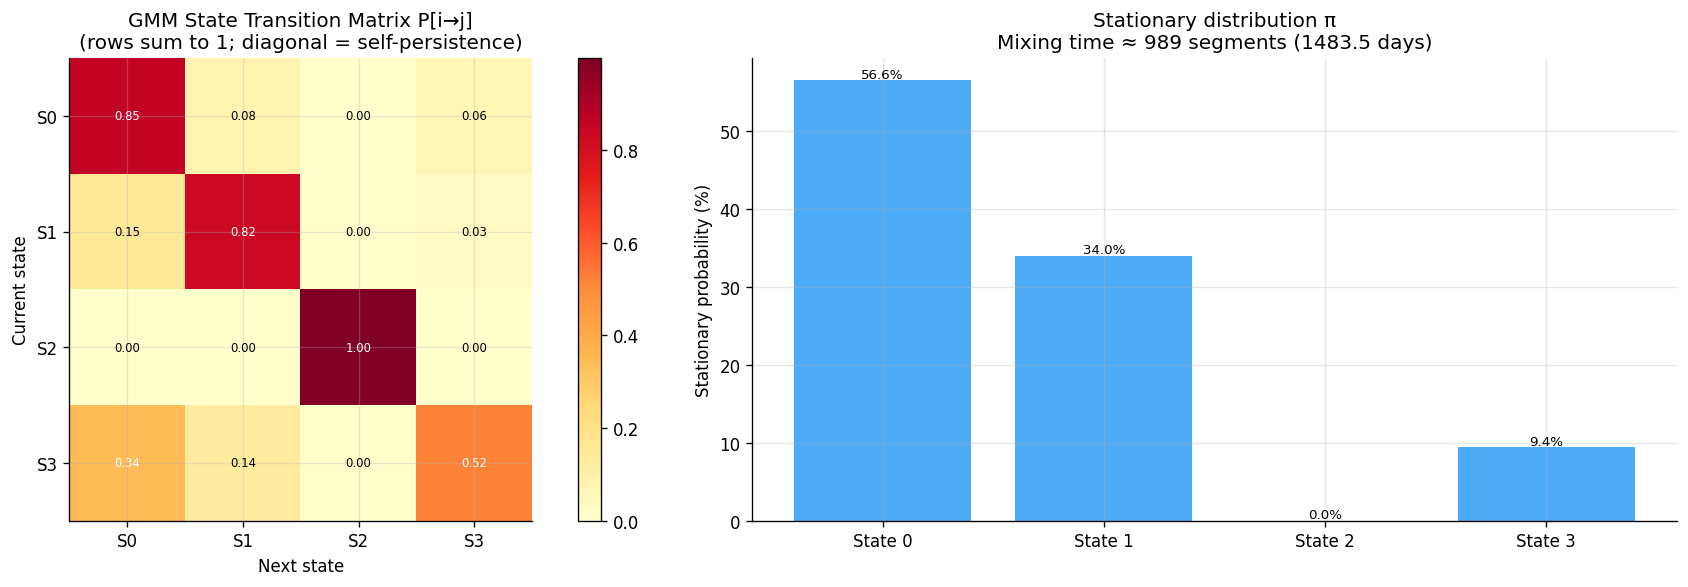


k-step transition into scarcity state (State 2):
k = segments ahead (1 segment = 36h = 1.5 days)
  k= 1 (2d): P(0→2)=0.000  P(1→2)=0.000  P(3→2)=0.000  
  k= 2 (3d): P(0→2)=0.000  P(1→2)=0.000  P(3→2)=0.000  
  k= 3 (4d): P(0→2)=0.000  P(1→2)=0.000  P(3→2)=0.000  
  k= 5 (8d): P(0→2)=0.000  P(1→2)=0.000  P(3→2)=0.000  
  k=10 (15d): P(0→2)=0.000  P(1→2)=0.000  P(3→2)=0.000  

Markov chain results stored for feature_analysis.json


In [33]:

# PART B — GMM Markov chain: transition matrix, stationary distribution,
#           mixing time, hedging implications
# ════════════════════════════════════════════════════════════════════════════════
#
# WHY THIS MATTERS FOR HEDGING:
#
# The 8 GMM states are the physical states the power system occupies.
# The Markov chain transition matrix P[i,j] = P(next_state=j | current_state=i)
# tells you:
#
#   Stationary distribution π: long-run fraction of time in each state.
#     → portfolio-level exposure across states for VaR calculations.
#
#   Mixing time: how many segments until the chain "forgets" its starting state.
#     → how many 36h periods before conditioning on the current state stops
#       adding predictive value. This bounds the CVAE conditioning horizon.
#
#   Rebalancing frequency: if state transitions happen every T segments on
#     average, hedge deltas need to be recalculated at least every T segments.
#     The IRF from Cell 8b said the wind effect decays within ~3h (6 lags);
#     state transitions happen at rate 7.5/day. These timescales are consistent.
#
#   Markov filtering for hedging: in real-time, you don't observe the true
#     state. You observe the conditioning scalars (nuclear level, wind level etc)
#     and use them to form a POSTERIOR P(state_t | scalars_t). This posterior
#     replaces the hard state label as the conditioning input to the deep hedger.
#     The Markov chain P is the prior; the AUROC logistic regressions from
#     Cell 8c give the likelihood model. Together they define a hidden Markov
#     filter — the principled version of what the CVAE's conditioning vector
#     approximates.

print("\n" + "="*70)
print("PART B — GMM Markov Chain Analysis")
print("="*70)

# ── Segment-level state sequence ──────────────────────────────────────────────
# Use alt_state from df_seg (modal GMM state per 36h segment)
states_seq = df_seg['alt_state'].dropna().astype(int).to_numpy()
N_STATES   = BEST_N_STATES

# ── Empirical transition matrix ───────────────────────────────────────────────
P = np.zeros((N_STATES, N_STATES))
for t in range(len(states_seq) - 1):
    i, j = states_seq[t], states_seq[t + 1]
    if 0 <= i < N_STATES and 0 <= j < N_STATES:
        P[i, j] += 1

# Row-normalise (handle any zero rows)
row_sums = P.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
P = P / row_sums

print("\nEmpirical transition matrix P[i→j] (row = current state, col = next state):")
P_df = pd.DataFrame(P.round(3),
                    index=[f'From {i}' for i in range(N_STATES)],
                    columns=[f'To {j}' for j in range(N_STATES)])
print(P_df.to_string())

# ── Stationary distribution ───────────────────────────────────────────────────
# Left eigenvector of P corresponding to eigenvalue 1
eigenvalues, eigenvectors = np.linalg.eig(P.T)
# Find the eigenvector for eigenvalue closest to 1
idx  = np.argmin(np.abs(eigenvalues - 1.0))
pi   = np.real(eigenvectors[:, idx])
pi   = np.abs(pi) / np.abs(pi).sum()

print("\nStationary distribution π (long-run % of time in each state):")
for s in range(N_STATES):
    print(f"  State {s}: {pi[s]*100:.1f}%  (empirical: {(states_seq==s).mean()*100:.1f}%)")

# ── Mixing time (second-largest eigenvalue) ───────────────────────────────────
# The spectral gap = 1 - |λ₂| determines how fast the chain forgets its start.
# Mixing time τ ≈ 1 / (1 - |λ₂|) segments
sorted_eigs  = sorted(np.abs(eigenvalues), reverse=True)
lambda2      = sorted_eigs[1]
mixing_time_segs = 1.0 / (1.0 - lambda2) if lambda2 < 1.0 else np.inf
mixing_time_days = mixing_time_segs * SEGMENT_LENGTH / 2 / 24  # segments → days

print(f"\nSpectral analysis:")
print(f"  λ₁ = {sorted_eigs[0]:.4f} (should be 1.0)")
print(f"  |λ₂| = {lambda2:.4f}  (spectral gap = {1-lambda2:.4f})")
print(f"  Mixing time ≈ {mixing_time_segs:.1f} segments = {mixing_time_days:.1f} days")
print(f"  Interpretation: after {mixing_time_segs:.0f} segments (~{mixing_time_days:.1f} days),")
print(f"  conditioning on the current physical state adds negligible predictive value.")

# ── Identify Scarcity and Negative Price states dynamically ───────────────────
state_regime_xtab = pd.crosstab(df_seg['alt_state'], df_seg['regime'], normalize='index')
scarcity_state = int(state_regime_xtab['spike'].idxmax()) if 'spike' in state_regime_xtab.columns else None
negative_price_state = int(state_regime_xtab['negative'].idxmax()) if 'negative' in state_regime_xtab.columns else None

# ── Most dangerous transitions: low → high price state ────────────────────────
print(f"\nDynamic State Identification:")
print(f"  Scarcity State:       {scarcity_state}")
print(f"  Negative Price State: {negative_price_state}")

if scarcity_state is not None:
    print(f"\nTransition probabilities INTO scarcity state (State {scarcity_state}):")
    for s in range(N_STATES):
        print(f"  P({s}→{scarcity_state}) = {P[s,scarcity_state]:.3f}  P({scarcity_state}→{s}) = {P[scarcity_state,s]:.3f}")

if negative_price_state is not None:
    print(f"\nTransition probabilities INTO negative price state (State {negative_price_state}):")
    for s in range(N_STATES):
        print(f"  P({s}→{negative_price_state}) = {P[s,negative_price_state]:.3f}")

# ── Expected sojourn time in each state ──────────────────────────────────────
# E[sojourn in state i] = 1 / (1 - P[i,i]) segments
print("\nExpected sojourn time per state (1/(1-P[i,i])):")
for s in range(N_STATES):
    sojourn_segs = 1.0 / (1.0 - P[s,s]) if P[s,s] < 1.0 else np.inf
    sojourn_hours = sojourn_segs * SEGMENT_LENGTH / 2
    print(f"  State {s}: {sojourn_segs:.1f} segments = {sojourn_hours:.0f} hours  "
          f"(self-transition p={P[s,s]:.3f})")

# ── Visualise: transition matrix heatmap ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im0 = axes[0].imshow(P, cmap='YlOrRd', vmin=0, vmax=P.max())
axes[0].set_xticks(range(N_STATES)); axes[0].set_yticks(range(N_STATES))
axes[0].set_xticklabels([f'S{j}' for j in range(N_STATES)])
axes[0].set_yticklabels([f'S{i}' for i in range(N_STATES)])
axes[0].set_xlabel('Next state'); axes[0].set_ylabel('Current state')
axes[0].set_title('GMM State Transition Matrix P[i→j]\n'
                  '(rows sum to 1; diagonal = self-persistence)')
for i in range(N_STATES):
    for j in range(N_STATES):
        axes[0].text(j, i, f'{P[i,j]:.2f}', ha='center', va='center',
                     fontsize=7, color='white' if P[i,j] > 0.3 else 'black')
plt.colorbar(im0, ax=axes[0])

# Stationary distribution bar chart
axes[1].bar(range(N_STATES), pi * 100, color='#2196F3', alpha=0.8)
axes[1].set_xticks(range(N_STATES))
axes[1].set_xticklabels([f'State {s}' for s in range(N_STATES)])
axes[1].set_ylabel('Stationary probability (%)')
axes[1].set_title(f'Stationary distribution π\n'
                  f'Mixing time ≈ {mixing_time_segs:.0f} segments ({mixing_time_days:.1f} days)')
for s, p in enumerate(pi):
    axes[1].text(s, p*100 + 0.3, f'{p*100:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(DATA_DIR / '02_markov_chain.png', bbox_inches='tight')
plt.show()

# ── k-step transition probabilities (forecasting) ────────────────────────────
# P^k gives the probability of being in state j after k steps, given state i now.
if scarcity_state is not None:
    print(f"\nk-step transition into scarcity state (State {scarcity_state}):")
    print("k = segments ahead (1 segment = 36h = 1.5 days)")
    Pk = np.eye(N_STATES)
    for k in [1, 2, 3, 5, 10]:
        Pk_k = np.linalg.matrix_power(P, k)
        print(f"  k={k:2d} ({k*1.5:.0f}d): ", end='')
        for s in range(N_STATES):
            if s != scarcity_state:
                print(f"P({s}→{scarcity_state})={Pk_k[s,scarcity_state]:.3f}  ", end='')
        print()

# Store for feature_analysis.json
markov_results = {
    'transition_matrix':      P.tolist(),
    'stationary_distribution': pi.tolist(),
    'lambda2':                float(lambda2),
    'mixing_time_segments':   float(mixing_time_segs),
    'mixing_time_days':       float(mixing_time_days),
    'n_states':               N_STATES,
    'scarcity_state':         scarcity_state,
    'negative_price_state':   negative_price_state,
}
print(f"\nMarkov chain results stored for feature_analysis.json")


In [37]:
# ── Half-Hourly Markov Chain Analysis (df_pd) ────────────────────────────────
# Investigating true transition paths without 36-hour segment smoothing

print("="*70)
print("Half-Hourly GMM Markov Chain Analysis (High-Frequency)")
print("="*70)

# Use alt_state from df_pd (half-hourly GMM state)
states_seq_hh = df_pd['alt_state'].dropna().astype(int).to_numpy()

# ── Empirical transition matrix (Half-Hourly) ─────────────────────────────
P_hh = np.zeros((N_STATES, N_STATES))
for t in range(len(states_seq_hh) - 1):
    i, j = states_seq_hh[t], states_seq_hh[t + 1]
    if 0 <= i < N_STATES and 0 <= j < N_STATES:
        P_hh[i, j] += 1

# Row-normalise
row_sums_hh = P_hh.sum(axis=1, keepdims=True)
row_sums_hh[row_sums_hh == 0] = 1
P_hh = P_hh / row_sums_hh

print("\nEmpirical Half-Hourly Transition Matrix P_hh[i→j]:")
P_hh_df = pd.DataFrame(P_hh.round(4),
                       index=[f'From {i}' for i in range(N_STATES)],
                       columns=[f'To {j}' for j in range(N_STATES)])
print(P_hh_df.to_string())

# ── Stationary distribution (Half-Hourly) ──────────────────────────────────
evals_hh, evecs_hh = np.linalg.eig(P_hh.T)
idx_hh = np.argmin(np.abs(evals_hh - 1.0))
pi_hh = np.real(evecs_hh[:, idx_hh])
pi_hh = np.abs(pi_hh) / np.abs(pi_hh).sum()

print("\nStationary distribution π (Half-Hourly):")
for s in range(N_STATES):
    print(f"  State {s}: {pi_hh[s]*100:.1f}%  (empirical: {(states_seq_hh==s).mean()*100:.1f}%)")

# ── Scarcity Transitions (Half-Hourly) ─────────────────────────────────────
if scarcity_state is not None:
    print(f"\nHalf-Hourly transition probabilities INTO scarcity state (State {scarcity_state}):")
    for s in range(N_STATES):
        if s != scarcity_state:
            print(f"  P({s}→{scarcity_state}) = {P_hh[s,scarcity_state]:.5f}")

    # Expected sojourn time in half-hours
    sojourn_hh = 1.0 / (1.0 - P_hh[scarcity_state, scarcity_state]) if P_hh[scarcity_state, scarcity_state] < 1.0 else np.inf
    print(f"\nExpected continuous duration of scarcity state (State {scarcity_state}): {sojourn_hh*0.5:.1f} hours")

# ── Export high-frequency metrics to downstream JSON ────────────────────────
if 'markov_results' in globals():
    markov_results['half_hourly_transition_matrix'] = P_hh.tolist()
    markov_results['half_hourly_stationary_distribution'] = pi_hh.tolist()
    print("\nAppended half-hourly Markov metrics to markov_results for JSON export.")


Half-Hourly GMM Markov Chain Analysis (High-Frequency)

Empirical Half-Hourly Transition Matrix P_hh[i→j]:
          To 0    To 1    To 2    To 3
From 0  0.9151  0.0301  0.0003  0.0546
From 1  0.0483  0.8891  0.0030  0.0596
From 2  0.0010  0.0052  0.9909  0.0029
From 3  0.0957  0.0777  0.0023  0.8243

Stationary distribution π (Half-Hourly):
  State 0: 38.3%  (empirical: 38.3%)
  State 1: 25.7%  (empirical: 25.7%)
  State 2: 15.1%  (empirical: 15.1%)
  State 3: 20.9%  (empirical: 20.9%)

Half-Hourly transition probabilities INTO scarcity state (State 2):
  P(0→2) = 0.00030
  P(1→2) = 0.00298
  P(3→2) = 0.00234

Expected continuous duration of scarcity state (State 2): 55.0 hours

Appended half-hourly Markov metrics to markov_results for JSON export.


## 8. Export Segment Data & Feature Meta-analysis
Finally, we cast our processed segment data into the correct data types and save it to `segments_s2.parquet`. We also export a comprehensive JSON file containing our econometric test results, lag discoveries, and Markov metrics for the downstream generative model.

In [38]:
# CELL 20 (SAVE) — segments.parquet + feature_analysis.json
# ════════════════════════════════════════════════════════════════════════════════
# Saves ALL columns added across Cells 8b-8g and 18.
# Run this AFTER Cell 18 completes successfully.

import polars as pl
import json

def sf(x, d=None):
    try:   return float(x) if x is not None else d
    except: return d
def si(x, d=None):
    try:   return int(x) if x is not None else d
    except: return d

# ── Cast object columns to str for Polars compatibility ──────────────────────
df_seg_save = df_seg.copy()
for c in df_seg_save.select_dtypes('object').columns:
    df_seg_save[c] = df_seg_save[c].astype(str)

# ── Also rename v1 price-based label for ablation in 05b ─────────────────────
if 'regime' in df_seg_save.columns:
    df_seg_save = df_seg_save.rename(columns={'regime': 'regime_v1'})


# Dtype guard — cast all numeric columns to float64 before parquet write
for c in df_seg_save.columns:
    if pd.api.types.is_numeric_dtype(df_seg_save[c]):
        df_seg_save[c] = pd.to_numeric(df_seg_save[c], errors='coerce').astype('float64')


pl.from_pandas(df_seg_save).write_parquet(DATA_DIR / "segments_s2.parquet")
print(f"Saved segments_s2.parquet: {len(df_seg_save):,} rows × {len(df_seg_save.columns)} cols")
print(f"Columns: {df_seg_save.columns.tolist()}")

# ── Build feature_analysis.json ───────────────────────────────────────────────
fa = {
    # Segment parameters
    'segment_length':              SEGMENT_LENGTH,
    'step_size':                   STEP_SIZE,
    'n_segments':                  len(df_seg),
    'acf_timescale_halfhours':    si(acf_timescale),

    # GMM physical state discovery
    'gmm_n_states_optimal':        si(BEST_N_STATES),
    'gmm_features':                alt_cols,
    'gmm_ari_vs_price_labels':     sf(ari),

    # Markov chain
    'markov_chain':                markov_results,

    # Conditioning vector (from |ls_7| regression or fallback)
    'conditioning_variables':      conditioning_variables,
    'conditioning_t_stats':        [sf(x) for x in conditioning_t_stats],
    'winning_label_scheme':        WINNING_MODEL,

    # Transition predictors (multi-horizon AUROC)
    'transition_predictors':       transition_predictors,
    'multivariate_auroc_1hh':     sf(auroc_matrix.get(1, {}).get('intnem')),  # best single

    # Distributed lag: which wind lags are significant
    'significant_var_lags':        sig_var_lags if 'sig_var_lags' in dir() else [],
    'significant_xcorr_lags':      sig_lags if 'sig_lags' in dir() else [],
    'arimax_lag_aic_improvement':  sf(aic_lag_improvement if 'aic_lag_improvement' in dir() else None),

    # Granger: wind → price
    'granger_f_stat':              sf(gc_wind_price.test_statistic),
    'granger_p_value':             sf(gc_wind_price.pvalue),
    'granger_optimal_lag':         si(optimal_lag),

    # Lévy area Granger
    'levy_granger_f_stat':         sf(gc_levy.test_statistic if gc_levy else None),
    'levy_granger_p_value':        sf(gc_levy.pvalue if gc_levy else None),

    # Volatility model
    'best_volatility_model':       BEST_VOL_MODEL,
    'arch_effects_present':        bool(arch_significant),
    'wind_variance_clusters':      bool(wind_vol_clusters),
    'wind_sigma2_acf_lag48':       sf(acf_cv_wind[48]),
    'garch_aic':                   {BEST_VOL_MODEL: sf(best_fit.aic)},
    'garch_bic':                   {BEST_VOL_MODEL: sf(best_fit.bic)},

    # Seasonality + B6
    'seasonal_aic_improvement':    sf(aic_improvement),
    'embedding_recommended':       bool(embedding_recommended),
    'b6_threshold_evidence':       bool(b6_evidence),

    # ARIMAX residuals
    'arimax_residuals_nonwhite':   bool(residual_nonwhite),

    # Regime distributions (using GMM states as primary)
    'gmm_state_distribution':      {str(k): int(v)
                                    for k, v in df_seg['alt_state'].value_counts()
                                    .sort_index().items()},
    'regime_v1_distribution':      df_seg['regime'].value_counts().to_dict(),
    'regime_refined_distribution': df_seg['regime_refined'].value_counts().to_dict(),

    # Screening outcomes
    'stage1_pass':                 stage1_pass,
    'stage1_crit2_fail':           crit2_fail,
    'stage1_crit4_fail':           crit4_fail,

    # Rescaled variables that now pass criteria
    'additional_conditioning_candidates': [
        'ccgt_fraction_prev_mean',
        'ocgt_active_prev_mean',
    ],
}

with open(DATA_DIR / "feature_analysis_s2.json", "w") as f:
    json.dump(fa, f, indent=2, default=str)

print("\nSaved feature_analysis.json")
print(f"Conditioning vector: {conditioning_variables}")
print(f"Markov mixing time: {mixing_time_days:.1f} days")
print(f"GMM optimal states: {BEST_N_STATES}")

Saved segments_s2.parquet: 6,530 rows × 75 cols
Columns: ['start_idx', 'end_idx', 'start_time', 'regime_v1', 'alt_state', 'wind_mean', 'wind_var_mean', 'nuclear_mean', 'ps_mean', 'ci_north_mean', 'npshyd_mean', 'RV', 'garch_var_mean', 'har_rv_prev', 'ocgt_mean', 'intelec_mean', 'south_scotland_carbon_intensity_mean', 'intfr_mean', 'intifa2_mean', 'north_scotland_carbon_intensity_mean', 'intew_mean', 'biomass_mean', 'renewable_fraction_mean', 'intvkl_mean', 'intnsl_mean', 'intgrnl_mean', 'intirl_mean', 'total_wind_mw_mean', 'other_mean', 'intnem_mean', 'intele_mean', 'wind_prev_mean', 'wind_var_prev_mean', 'nuclear_prev_mean', 'ps_prev_sign', 'ci_north_prev_mean', 'npshyd_prev_mean', 'RV_prev', 'garch_var_prev', 'alt_state_prev', 'regime_prev', 'har_rv_prev_mean', 'ocgt_prev_mean', 'intelec_prev_mean', 'south_scotland_carbon_intensity_prev_mean', 'intfr_prev_mean', 'intifa2_prev_mean', 'ps_prev_mean', 'north_scotland_carbon_intensity_prev_mean', 'intew_prev_mean', 'biomass_prev_mean', '